# BASELINE A2 — Emoji-Expanded Text **WITHOUT** the Intent Vector

**Controlled ablation of the emoji-intent pathway.** This notebook is a strict
single-factor variant of the *Emoji-Intent-Aware Multitask* pipeline. It keeps the
emoji → Bangla-phrase expansion (Section 3) fully intact, so the model still receives
every emoji as *lexical/semantic* content through the tokenizer — but the explicit,
leakage-free **statistical intent vector** (sarcasm/offensive propensities, position and
density features) and its projection MLP are **removed** from the architecture. The
classifier therefore sees **only the 768-d `[CLS]` representation** of BanglaBERT.

**Hypothesis under test:** *does explicit, leakage-free intent encoding (propensity
statistics) provide statistical signal beyond simply converting emojis to text?*

Everything else is held fixed against the reference run: identical 5-fold
`StratifiedKFold` splits and seed (**42**), identical hyper-parameters (inherited from
the reference checkpoint), the **cross-stitch** soft-sharing unit, the
**uncertainty-weighted multitask loss**, the **supervised-contrastive** auxiliary loss,
the emoji-cluster augmentation, the data paths and the full evaluation/statistics suite.
Any difference in performance is therefore attributable to the intent vector alone.


## Section 0 — Environment, Dependencies & Global Configuration

In [1]:
# Colab/Kaggle: install once.  (SHAP removed — not used anymore.)
# NOTE: version-sensitive packages are UPGRADED (-U) and pinned to a floor, so a
# stale pre-installed build cannot linger. A too-old `lime` is what lacked the
# `split_expr` kwarg used in Section 14; a too-old `hyperopt` rejects the
# default_rng `rstate` in Section 11.
!pip install -q -U "lime>=0.2.0.1" "hyperopt>=0.2.7"
!pip install -q "transformers>=4.40" "datasets" "scikit-learn" "pandas" "numpy" \
                "openpyxl" "emoji>=2.10" "scipy" \
                "matplotlib" "seaborn" "tqdm"

# BanglaBERT REQUIRES the csebuetnlp text normalizer to be applied BEFORE tokenizing
# (see Section 3). Install it here; the import is guarded in Section 3 so the notebook
# still runs (with a warning) if this install is unavailable in an offline environment.
!pip install -q "git+https://github.com/csebuetnlp/normalizer"


  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.0/185.0 kB 4.9 MB/s eta 0:00:0000:01
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.2/64.2 kB 4.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [2]:
import os, re, random, copy, warnings, math
import numpy as np, pandas as pd
import torch, torch.nn as nn, torch.nn.functional as F
import emoji as emojilib
warnings.filterwarnings("ignore")

# ---- Reproducibility ----------------------------------------------------------
SEED = 42
def seed_everything(seed=SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
seed_everything()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- Global configuration -----------------------------------------------------
CFG = {
    "QUICK_SMOKE_TEST": False,    # True -> tiny/fast end-to-end sanity run
    "MODEL_NAME":   "csebuetnlp/banglabert",   # Bangla-specific ELECTRA-discriminator (hidden=768, same as XLM-R base)
    "MAX_LEN":      96,           # texts are <=15 words (99th pct 12) -> 96 is ample & ~1.8x faster than 128
    "N_SPLITS":     5,
    "TEST_SIZE":    0.15,
    "MAX_EPOCHS":   20,           # ceiling only — early stopping usually ends sooner
    "PATIENCE":     3,
    "SCHED_EPOCHS": 12,           # LR anneals over THIS horizon (decoupled from MAX_EPOCHS)
                                  #   -> avoids a too-high LR when early stopping fires early
    "WARMUP_RATIO": 0.1,
    "WEIGHT_DECAY": 0.01,         # CONSISTENT across train / hyperopt / ablation
    "GRAD_CLIP":    1.0,
    "USE_SUPCON":   True,         # supervised-contrastive auxiliary loss
    "SUPCON_W":     0.1,
    "INTENT_MIN_COUNT": 3,        # emoji must appear >=N times (in TRAIN) to get a prop
    "INTENT_SMOOTH_M":  5.0,      # m-estimate smoothing strength toward train base-rate
    "HPO_MAX_EVALS": 10,
    "HPO_PROXY_SIZE": 1000,
    "HPO_PROXY_EPOCHS": 3,

    # ---- NEW: repeated-runs & statistical-significance controls ----------------
    "N_RUNS":       10,           # 10 seeds for reproducibility (Q1 requirement). Lower to 5 to halve runtime.
    "SEED_LIST":    [42, 1, 2, 3, 4, 5, 6, 7, 8, 9],
    "ABLATION_SEED": 42,          # ablations trained at this seed so McNemar pairs with Run-1's test set
    "SKIP_HPO":     False,        # True -> reuse DEFAULT_HP (skips the search, saves time)
    "BOOTSTRAP_N":  5000,         # bootstrap resamples for CIs / performance-vs-random p-value
    "PERM_N":       2000,         # label-permutation resamples for the "better-than-chance" p-value
    "N_LIME_EXAMPLES": 40,        # emoji-bearing test examples used for the emoji>word t-test
    "LIME_SAMPLES": 300,          # LIME perturbations per example
    "RUN_DIR":      "/kaggle/working/runs",   # per-seed checkpoints (resume-safe)
}
# Sensible fallback if HPO is skipped
DEFAULT_HP = {"lr": 2e-5, "batch_size": 16, "dropout": 0.3, "shared_dim": 512, "task_dim": 256}

if CFG["QUICK_SMOKE_TEST"]:
    CFG.update(MAX_EPOCHS=2, PATIENCE=1, SCHED_EPOCHS=2, N_SPLITS=2, HPO_MAX_EVALS=3,
               HPO_PROXY_SIZE=200, HPO_PROXY_EPOCHS=1, N_RUNS=2,
               SEED_LIST=[42, 1], BOOTSTRAP_N=500, PERM_N=200,
               N_LIME_EXAMPLES=5, LIME_SAMPLES=80)

CFG["SEED_LIST"] = CFG["SEED_LIST"][:CFG["N_RUNS"]]
os.makedirs(CFG["RUN_DIR"], exist_ok=True)

print(f"Device: {DEVICE} | torch {torch.__version__} | emoji {emojilib.__version__}")
print("QUICK_SMOKE_TEST =", CFG["QUICK_SMOKE_TEST"], "| N_RUNS =", CFG["N_RUNS"],
      "| SEEDS =", CFG["SEED_LIST"])

Device: cuda | torch 2.10.0+cu128 | emoji 1.4.2
QUICK_SMOKE_TEST = False | N_RUNS = 10 | SEEDS = [42, 1, 2, 3, 4, 5, 6, 7, 8, 9]


## Section 1 — Dataset Loading, Verified Statistics & Integrity Checks

We load AUST-SARC from whichever location exists (Colab upload, Kaggle, or local), **verify the label distributions programmatically**, and remove exact-duplicate `(text, sarcasm, offensive)` rows. Removing identical rows is a *leakage-prevention* step: the same sentence in both train and test would otherwise inflate scores. Counts are reported transparently.

> **Note on size (2,648 vs 2,649):** the project brief and one audit cite 2,649; the distributed `.xlsx` contains **2,648** labelled rows (header excluded). We use the verified count from the file and surface the discrepancy rather than hard-coding either number.

In [3]:
# # ---- Explore directory to find the Excel file -----
# DATA_DIR = "/kaggle/input/datasets/hamed999/sarc-off-banglabert/"

# # List all files in the directory
# print("Files in directory:")
# print(os.listdir(DATA_DIR))

# # Find the Excel file (look for .xlsx or .xls)
# excel_files = [f for f in os.listdir(DATA_DIR) if f.endswith(('.xlsx', '.xls'))]
# print(f"\nExcel files found: {excel_files}")

# if not excel_files:
#     raise FileNotFoundError(f"No Excel files found in {DATA_DIR}")

# # Use the first Excel file found
# DATA_PATH = os.path.join(DATA_DIR, excel_files[0])
# print(f"\nUsing file: {DATA_PATH}")

# df_raw = pd.read_excel(DATA_PATH)
# df_raw.columns = ["text", "sarcasm", "offensive"]
# print("Loaded:", DATA_PATH, "| raw shape:", df_raw.shape)
# df_raw.head()



# ---- Install and import kagglehub -----
!pip install -q kagglehub

import kagglehub
import os
import pandas as pd

# ---- Explore directory to find the Excel file -----
DATA_DIR = kagglehub.dataset_download("hamed999/multi-task-bengali-sarcasm-and-offensiveness-dataset")

# List all files in the directory
print("Files in directory:")
print(os.listdir(DATA_DIR))

# Find the Excel file (look for .xlsx or .xls)
excel_files = [f for f in os.listdir(DATA_DIR) if f.endswith(('.xlsx', '.xls'))]
print(f"\nExcel files found: {excel_files}")

if not excel_files:
    raise FileNotFoundError(f"No Excel files found in {DATA_DIR}")

# Use the first Excel file found
DATA_PATH = os.path.join(DATA_DIR, excel_files[0])
print(f"\nUsing file: {DATA_PATH}")

df_raw = pd.read_excel(DATA_PATH)
df_raw.columns = ["text", "sarcasm", "offensive"]
print("Loaded:", DATA_PATH, "| raw shape:", df_raw.shape)
df_raw.head()

Files in directory:
['aust-sarc.xlsx']

Excel files found: ['aust-sarc.xlsx']

Using file: /kaggle/input/datasets/hamed999/multi-task-bengali-sarcasm-and-offensiveness-dataset/aust-sarc.xlsx
Loaded: /kaggle/input/datasets/hamed999/multi-task-bengali-sarcasm-and-offensiveness-dataset/aust-sarc.xlsx | raw shape: (2648, 3)


,text,sarcasm,offensive
0,করিম এর বুদ্ধি প্রশংসনীয় 🤣,1,0
1,সে অনেক ভদ্র 🤣,1,0
2,ও ভালোই লম্বা 🤣,1,1
3,ওর অনেক সুন্দর স্বাস্থ 🤣,1,1
4,সে পরিমিত খায় 🤣,1,1


In [4]:
# ---- Integrity + verified label distributions --------------------------------
assert set(df_raw["sarcasm"].unique()) <= {0, 1}
assert set(df_raw["offensive"].unique()) <= {0, 1}
assert df_raw[["text", "sarcasm", "offensive"]].isnull().sum().sum() == 0

n_dup = df_raw.duplicated(subset=["text", "sarcasm", "offensive"]).sum()
df = df_raw.drop_duplicates(subset=["text", "sarcasm", "offensive"]).reset_index(drop=True)

# Text-level duplicates that survive (same text, CONFLICTING labels) are a
# potential train/test leakage source. We report them; set DEDUP_ON_TEXT=True
# to also drop them (keeps the first occurrence) for a stricter split.
DEDUP_ON_TEXT = False
n_text_dup = df.duplicated(subset=["text"]).sum()
if DEDUP_ON_TEXT and n_text_dup:
    df = df.drop_duplicates(subset=["text"]).reset_index(drop=True)

print("=== DATASET STATISTICS (verified from file) ===")
print(f"Raw rows                  : {len(df_raw)}")
print(f"Exact-duplicate rows      : {n_dup}  (removed)")
print(f"Text-only duplicates left : {n_text_dup}  "
      f"({'removed' if DEDUP_ON_TEXT else 'kept — set DEDUP_ON_TEXT=True to drop'})")
print(f"Working rows              : {len(df)}")
print(f"Sarcasm=1 / Sarcasm=0     : {(df.sarcasm==1).sum()} / {(df.sarcasm==0).sum()}")
print(f"Offensive=1 / Offensive=0 : {(df.offensive==1).sum()} / {(df.offensive==0).sum()}")
print("\n=== JOINT LABEL DISTRIBUTION ===")
joint_tab = (df.groupby(["sarcasm","offensive"]).size().reset_index(name="count"))
joint_tab["category"] = ["Clean/Literal","Explicit Abuse","Pure Sarcasm","Sarcastic Abuse"]
print(joint_tab.to_string(index=False))

=== DATASET STATISTICS (verified from file) ===
Raw rows                  : 2648
Exact-duplicate rows      : 15  (removed)
Text-only duplicates left : 3  (kept — set DEDUP_ON_TEXT=True to drop)
Working rows              : 2633
Sarcasm=1 / Sarcasm=0     : 1484 / 1149
Offensive=1 / Offensive=0 : 1277 / 1356

=== JOINT LABEL DISTRIBUTION ===
 sarcasm  offensive  count        category
       0          0    345   Clean/Literal
       0          1    804  Explicit Abuse
       1          0   1011    Pure Sarcasm
       1          1    473 Sarcastic Abuse


## Section 2 — Emoji Extraction & Corpus Analysis (library-based)

All emoji handling uses the **`emoji` library** (`EMOJI_DATA`), which covers supplemental symbols, variation selectors, regional indicators and ZWJ sequences — the cases the old hand-written regex missed.

In [5]:
from collections import Counter, defaultdict

# ---- Version-robust emoji lookup ---------------------------------------------
# `emoji>=2.10` (this notebook's floor) exposes `EMOJI_DATA` — a dict {char: {...}}.
# Some kernels ship a newer/older build where it's named `UNICODE_EMOJI`, is a
# function `is_emoji()`, or lives under a private path. We resolve ONCE here and
# expose:
#   * EMOJI_SET  — a set of every recognised emoji character (fast membership test)
#   * emoji_name(ch) — English short-name for the fallback token in Section 3
# We also monkey-patch `emojilib.EMOJI_DATA` back onto the module so the many
# downstream cells that read `emojilib.EMOJI_DATA` directly keep working unchanged.

def _resolve_emoji_api():
    # 1) modern (emoji 2.x): dict at emojilib.EMOJI_DATA
    d = getattr(emojilib, "EMOJI_DATA", None)
    if isinstance(d, dict) and d:
        return d, "EMOJI_DATA"
    # 2) older path (emoji <2.x): UNICODE_EMOJI["en"]
    u = getattr(emojilib, "UNICODE_EMOJI", None)
    if isinstance(u, dict):
        d = u.get("en") or next(iter(u.values()), None)
        if isinstance(d, dict) and d:
            # normalise to {char: {"en": ":short_name:"}} shape
            norm = {ch: (v if isinstance(v, dict) else {"en": v}) for ch, v in d.items()}
            return norm, "UNICODE_EMOJI"
    # 3) private module (emoji 3.x kept the same dict, moved the export)
    try:
        from emoji.unicode_codes.data_dict import EMOJI_DATA as _D
        if isinstance(_D, dict) and _D:
            return _D, "unicode_codes.data_dict"
    except Exception:
        pass
    # 4) last-resort: use is_emoji() to enumerate BMP+SMP; slow but correct
    if hasattr(emojilib, "is_emoji"):
        d = {}
        for cp in range(0x1F000, 0x1FB00):        # main emoji planes
            ch = chr(cp)
            try:
                if emojilib.is_emoji(ch):
                    d[ch] = {"en": f":U+{cp:04X}:"}
            except Exception:
                pass
        for cp in range(0x2600, 0x27C0):          # misc symbols/dingbats
            ch = chr(cp)
            try:
                if emojilib.is_emoji(ch):
                    d[ch] = {"en": f":U+{cp:04X}:"}
            except Exception:
                pass
        if d:
            return d, "is_emoji() enumeration"
    raise ImportError(
        f"Unsupported `emoji` package layout (version={getattr(emojilib,'__version__','?')}). "
        f"Fix: !pip install -U --force-reinstall 'emoji>=2.10,<3'  and restart the kernel."
    )

_EMOJI_DATA, _src = _resolve_emoji_api()
EMOJI_SET = set(_EMOJI_DATA.keys())

# Monkey-patch so every downstream cell that reads `emojilib.EMOJI_DATA` keeps working
# without edits (LIME, ambiguity score, robustness, error analysis, etc.).
emojilib.EMOJI_DATA = _EMOJI_DATA

def emoji_name(ch):
    """Return an English short-name for `ch` (used by expand_emojis' fallback token)."""
    rec = _EMOJI_DATA.get(ch, {})
    if isinstance(rec, dict):
        return rec.get("en") or rec.get("alias") or ":unknown:"
    return str(rec)

print(f"emoji API resolved via: {_src}  |  {len(EMOJI_SET)} characters recognised  "
      f"|  emoji lib v{getattr(emojilib,'__version__','?')}")

# ---- Corpus analysis (uses the resolved EMOJI_SET) ---------------------------
def extract_emojis(text):
    """Return the list of emoji characters in text (library-backed, complete)."""
    return [c for c in str(text) if c in EMOJI_SET]

df["emojis"]      = df["text"].apply(extract_emojis)
df["emoji_count"] = df["emojis"].apply(len)

emoji_freq = Counter(e for lst in df["emojis"] for e in lst)
print(f"Sentences with >=1 emoji : {(df.emoji_count>0).sum()} / {len(df)} "
      f"({(df.emoji_count>0).mean()*100:.1f}%)")
print(f"Mean emojis / sentence   : {df.emoji_count.mean():.2f}")
print(f"Distinct emojis in corpus: {len(emoji_freq)}")
print("\nTop-15 emojis:")
for e, n in emoji_freq.most_common(15):
    print(f"  {e}  {n:>4}  {emoji_name(e)}")

emoji API resolved via: UNICODE_EMOJI  |  3521 characters recognised  |  emoji lib v1.4.2
Sentences with >=1 emoji : 2599 / 2633 (98.7%)
Mean emojis / sentence   : 1.33
Distinct emojis in corpus: 293

Top-15 emojis:
  🤣   456  :rolling_on_the_floor_laughing:
  😂   372  :face_with_tears_of_joy:
  😡   305  :pouting_face:
  😑   198  :expressionless_face:
  😠   161  :angry_face:
  😒   137  :unamused_face:
  ❤   123  :red_heart:
  😆   104  :grinning_squinting_face:
  😭    84  :loudly_crying_face:
  🐸    84  :frog:
  😍    57  :smiling_face_with_heart-eyes:
  🧡    49  :orange_heart:
  🙄    47  :face_with_rolling_eyes:
  😤    47  :face_with_steam_from_nose:
  😏    45  :smirking_face:


## Section 3 — Emoji → Bangla Phrase Expansion (full corpus coverage)

convert emojis to Bangla phrases to surface their hidden emotional/pragmatic context. Here:

* a **curated Bangla dictionary** handles the most frequent ~70 emojis (≈84 % of all emoji occurrences) with sarcasm/offence-aware wording, and
* every remaining emoji falls back to a **distinct** `[ইমোজি: <name>]` token derived from the `emoji` library's short-name — so no two emojis collapse together.

This yields **100 % coverage with full semantic distinction**.

In [6]:
# ---- Curated Bangla phrases for high-frequency, intent-bearing emojis ----------

# ---- BanglaBERT text normalizer (REQUIRED before tokenizing) -------------------
# BanglaBERT was pretrained on text passed through csebuetnlp's normalizer; applying
# the same normalization at fine-tune/inference time is required for best results.
# Guarded so the notebook still runs (identity normalize + warning) if the package
# is missing (e.g. offline). Normalization is applied LAST, on the final Bangla
# string, right before tokenization — never on raw emoji characters.
try:
    from normalizer import normalize as _bnorm
    _NORMALIZER_OK = True
except Exception as _e:
    warnings.warn(f"csebuetnlp normalizer unavailable ({_e}); using identity normalize. "
                  f"Install: pip install git+https://github.com/csebuetnlp/normalizer")
    def _bnorm(t):
        return t
    _NORMALIZER_OK = False

def bnorm(text):
    """Apply the BanglaBERT normalizer with a safe fallback to identity."""
    try:
        return _bnorm(str(text))
    except Exception:
        return str(text)
CURATED_BANGLA = {
    "🤣":"[ব্যঙ্গাত্মক হাসি]", "😂":"[কান্নাময় হাসি]", "😆":"[উচ্চস্বরে হাসি]",
    "😁":"[উজ্জ্বল হাসি]", "😃":"[প্রশস্ত হাসি]", "🙂":"[মৃদু হাসি]", "😊":"[সন্তুষ্ট হাসি]",
    "😏":"[বাঁকা হাসি]", "😎":"[আত্মবিশ্বাসী]", "😉":"[চোখ টিপ]", "🤡":"[সং]",
    "🐸":"[ব্যঙ্গ প্রতীক]", "🙃":"[উল্টো হাসি]",
    "😡":"[রাগান্বিত]", "😠":"[ক্ষুব্ধ]", "🤬":"[গালিগালাজ]", "😤":"[ক্রুদ্ধ শ্বাস]",
    "😒":"[অসন্তুষ্ট]", "😑":"[বিরক্ত]", "😐":"[নির্বিকার]", "🙄":"[চোখ ঘোরানো]",
    "🤮":"[বিতৃষ্ণা]", "🤢":"[বমি ভাব]", "💀":"[মৃত্যু প্রতীক]", "👎":"[অপছন্দ]",
    "🖕":"[অশ্লীল অঙ্গভঙ্গি]",
    "😭":"[কাঁদছি]", "😢":"[দুঃখী]", "😔":"[বিষণ্ণ]", "😞":"[হতাশ]", "😟":"[উদ্বিগ্ন]",
    "😫":"[ক্লান্ত]", "😩":"[বিরক্ত ক্লান্ত]", "😣":"[কষ্ট]", "😓":"[ঘর্মাক্ত]",
    "😪":"[ঘুমঘুম]", "😴":"[ঘুমন্ত]", "🥲":"[অশ্রুসিক্ত হাসি]", "💔":"[ভাঙা হৃদয়]",
    "😍":"[মুগ্ধ]", "🥰":"[ভালোবাসাময়]", "😘":"[চুম্বন]", "❤":"[ভালোবাসা]",
    "🧡":"[কমলা হৃদয়]", "💛":"[হলুদ হৃদয়]", "💙":"[নীল হৃদয়]", "💚":"[সবুজ হৃদয়]",
    "💯":"[একশো ভাগ]", "🔥":"[আগুন]", "👏":"[তালি]", "👍":"[পছন্দ]", "🙏":"[প্রার্থনা]",
    "😳":"[লজ্জিত]", "😮":"[বিস্মিত]", "😯":"[অবাক]", "😵":"[হতবিহ্বল]", "🥴":"[বিভ্রান্ত]",
    "🤔":"[ভাবছি]", "🤦":"[হতাশ ভঙ্গি]", "🤷":"[কাঁধ ঝাঁকানো]", "😶":"[নিরুত্তর]",
    "👀":"[নজর]", "🎭":"[নাটকীয়তা]",
}

def expand_emojis(text):
    """Replace every emoji with a Bangla phrase; tail emojis get a DISTINCT named token."""
    out = []
    for ch in str(text):
        if ch in CURATED_BANGLA:
            out.append(f" {CURATED_BANGLA[ch]} ")
        elif ch in emojilib.EMOJI_DATA:
            name = emojilib.EMOJI_DATA[ch]["en"].strip(":").replace("_", " ")
            out.append(f" [ইমোজি: {name}] ")
        else:
            out.append(ch)
    return re.sub(r"\s+", " ", "".join(out)).strip()

def strip_emojis(text):
    """Delete every emoji character entirely (for the TRUE no-emoji ablation)."""
    return "".join(ch for ch in str(text) if ch not in emojilib.EMOJI_DATA)

def clean_text(text):
    text = re.sub(r"http\S+|www\.\S+", "", str(text))
    text = re.sub(r"[@#]\w+", "", text)
    return re.sub(r"\s+", " ", text).strip()

def preprocess(text):                       # raw -> model-input (emoji-EXPANDED) text
    return bnorm(expand_emojis(clean_text(text)))       # normalize LAST, before tokenizing

def preprocess_noemoji(text):               # raw -> model-input with emojis REMOVED (ablation A0)
    return bnorm(clean_text(strip_emojis(text)))        # normalize LAST, before tokenizing

covered = sum(emoji_freq[e] for e in CURATED_BANGLA if e in emoji_freq)
print(f"Curated map: {len(CURATED_BANGLA)} emojis -> covers "
      f"{covered}/{sum(emoji_freq.values())} = {covered/sum(emoji_freq.values())*100:.1f}% of occurrences")
print("Tail emojis still get a DISTINCT token (no generic collapse).")
print(f"BanglaBERT normalizer active: {_NORMALIZER_OK}")
for s in df["text"].iloc[[1, 3]]:
    print(f"\n  raw       : {s}\n  expanded  : {preprocess(s)}\n  no-emoji  : {preprocess_noemoji(s)}")

Curated map: 63 emojis -> covers 2841/3492 = 81.4% of occurrences
Tail emojis still get a DISTINCT token (no generic collapse).
BanglaBERT normalizer active: True

  raw       : সে অনেক ভদ্র 🤣
  expanded  : সে অনেক ভদ্র [ব্যঙ্গাত্মক হাসি]
  no-emoji  : সে অনেক ভদ্র

  raw       : ওর অনেক সুন্দর স্বাস্থ 🤣
  expanded  : ওর অনেক সুন্দর স্বাস্থ [ব্যঙ্গাত্মক হাসি]
  no-emoji  : ওর অনেক সুন্দর স্বাস্থ


## Section 4 — Leakage-Free Emoji *Intent* Encoder (core novelty)

**This is the central contribution**

Each emoji gets a **sarcasm propensity** and **offensive propensity** estimated from the corpus — *task-specific intent*, not generic emotion. 

Here the statistics live in an **`EmojiIntentEncoder`** with a strict **`fit` / `transform`** contract:

* `fit(texts, sarc, off)` is called **only on a training split** (each CV fold's train part, or the full train/CV pool for the final hold-out model);
* low-frequency emojis are smoothed toward the **training base-rate** via an **m-estimate** `(hits + m·base)/(n + m)` instead of an arbitrary `0.5`;
* `transform(texts)` applies those frozen training statistics to *any* split.

The 10-d sentence vector `[max_sarc, mean_sarc, max_off, mean_off, emoji_count, sarc_anchors, off_anchors, first_pos, last_pos, density]` — **all 10 dims are fed to the model** (the audit's "position features unused" concern is explicitly avoided).

In [7]:
class EmojiIntentEncoder:
    """Corpus-derived, leakage-free per-emoji sarcasm/offensive propensity features."""
    def __init__(self, min_count=None, m=None, sarc_thresh=0.60, off_thresh=0.60):
        self.min_count = CFG["INTENT_MIN_COUNT"] if min_count is None else min_count
        self.m         = CFG["INTENT_SMOOTH_M"]  if m is None else m
        self.sarc_thresh, self.off_thresh = sarc_thresh, off_thresh
        self.sarc_prop, self.off_prop = {}, {}
        self.base_sarc, self.base_off = 0.5, 0.5
        self.dim = 10
        self.cols = ["ei_max_sarc","ei_mean_sarc","ei_max_off","ei_mean_off",
                     "ei_count","ei_sarc_anchors","ei_off_anchors",
                     "ei_first_pos","ei_last_pos","ei_density"]

    def fit(self, texts, sarc, off):
        sarc = np.asarray(sarc); off = np.asarray(off)
        self.base_sarc, self.base_off = float(sarc.mean()), float(off.mean())
        stat = defaultdict(lambda: {"s":0, "o":0, "n":0})
        for t, s, o in zip(texts, sarc, off):
            for e in extract_emojis(t):
                stat[e]["n"] += 1; stat[e]["s"] += int(s); stat[e]["o"] += int(o)
        for e, d in stat.items():
            if d["n"] >= self.min_count:               # m-estimate smoothing
                self.sarc_prop[e] = (d["s"] + self.m*self.base_sarc) / (d["n"] + self.m)
                self.off_prop[e]  = (d["o"] + self.m*self.base_off ) / (d["n"] + self.m)
        return self

    def _vec(self, text):
        ems = extract_emojis(text); t = str(text); n = len(t)
        if not ems:
            return [self.base_sarc, self.base_sarc, self.base_off, self.base_off,
                    0.0, 0.0, 0.0, 0.5, 0.5, 0.0]
        s = [self.sarc_prop.get(e, self.base_sarc) for e in ems]
        o = [self.off_prop.get(e,  self.base_off ) for e in ems]
        return [max(s), float(np.mean(s)), max(o), float(np.mean(o)), float(len(ems)),
                float(sum(x >= self.sarc_thresh for x in s)),
                float(sum(x >= self.off_thresh  for x in o)),
                t.find(ems[0]) / max(n,1), t.rfind(ems[-1]) / max(n,1),
                len(ems) / max(len(t.split()),1)]

    def transform(self, texts):
        return np.asarray([self._vec(t) for t in texts], dtype=np.float32)

# sanity demo (fit on a slice; NOT used for any reported metric)
_demo = EmojiIntentEncoder().fit(df.text.values, df.sarcasm.values, df.offensive.values)
print("Encoder demo — distinct emojis with learned propensities:", len(_demo.sarc_prop),
      "| base sarc/off:", round(_demo.base_sarc,3), round(_demo.base_off,3))
print("Example vector dim:", _demo.transform([df.text.iloc[1]]).shape)

Encoder demo — distinct emojis with learned propensities: 144 | base sarc/off: 0.564 0.485
Example vector dim: (1, 10)


## Section 5 — Stratified Hold-out Test Split (done BEFORE any fitting)

A 15 % hold-out test set is carved out **first**, stratified on the **joint**
`(sarcasm, offensive)` label so all four cells are represented. Nothing about this set
informs preprocessing, the intent encoder, hyper-parameters, or training.

In [8]:
from sklearn.model_selection import train_test_split, StratifiedKFold

def joint_label(frame):
    return (frame.sarcasm.astype(str) + frame.offensive.astype(str)) \
            .map({"00":0, "01":1, "10":2, "11":3}).values

joint_all = joint_label(df)
tr_idx, te_idx = train_test_split(
    np.arange(len(df)), test_size=CFG["TEST_SIZE"],
    random_state=SEED, stratify=joint_all)

df_trainval = df.iloc[tr_idx].reset_index(drop=True)
df_test     = df.iloc[te_idx].reset_index(drop=True)
joint_trainval = joint_label(df_trainval)

print(f"Train/CV pool : {len(df_trainval)}")
print(f"Hold-out test : {len(df_test)}")
print(f"Test  Sarc 1/0: {(df_test.sarcasm==1).sum()}/{(df_test.sarcasm==0).sum()}  |  "
      f"Off 1/0: {(df_test.offensive==1).sum()}/{(df_test.offensive==0).sum()}")

Train/CV pool : 2238
Hold-out test : 395
Test  Sarc 1/0: 223/172  |  Off 1/0: 191/204


## Section 6 — Emoji-Cluster Data Augmentation (train-only, seeded)

Augmentation swaps an emoji for a semantically similar one within the same intent
cluster. Two audit fixes: (a) the clusters now cover the **frequent** corpus emojis
(the old version was dead code for most samples), and (b) the RNG is **re-seeded per
fold** for reproducibility. Augmentation is applied to **training folds only**.

In [9]:
# Intent clusters built from the most frequent emojis (so swaps actually fire)
SARC_CLUSTER    = ["🤣","😂","😆","😁","😏","🐸","🤡","🙃","😎"]
OFF_CLUSTER     = ["😡","😠","🤬","😤","😒","🙄","🤮","🤢","💀"]
SAD_CLUSTER     = ["😭","😢","😔","😞","😟","😫","😩","😣","😓","💔"]
POS_CLUSTER     = ["😍","🥰","😘","❤","🧡","💛","💙","💚","👍","👏"]
CLUSTERS = [SARC_CLUSTER, OFF_CLUSTER, SAD_CLUSTER, POS_CLUSTER]
EMOJI_TO_CLUSTER = {e: c for c in CLUSTERS for e in c}

def augment_emoji_substitution(text, p=0.3, rng=random):
    """With prob p, swap ONE in-cluster emoji for a sibling. Operates on RAW text."""
    if rng.random() > p:
        return text
    chars = list(str(text))
    swap_positions = [i for i, ch in enumerate(chars) if ch in EMOJI_TO_CLUSTER]
    if not swap_positions:
        return text
    i = rng.choice(swap_positions)
    opts = [e for e in EMOJI_TO_CLUSTER[chars[i]] if e != chars[i]]
    if opts:
        chars[i] = rng.choice(opts)
    return "".join(chars)

_rng = random.Random(SEED)
ex = df_trainval.text.iloc[0]
print("orig :", ex)
print("aug  :", augment_emoji_substitution(ex, p=1.0, rng=_rng))
print(f"\nEmojis covered by clusters: {len(EMOJI_TO_CLUSTER)} "
      f"(accounts for {sum(emoji_freq[e] for e in EMOJI_TO_CLUSTER if e in emoji_freq)} occurrences)")

orig : থাবড় খাবি? 😊
aug  : থাবড় খাবি? 😊

Emojis covered by clusters: 38 (accounts for 2367 occurrences)


## Section 7 — `A2-MTL-BanglaBERT` Model Architecture (no intent vector)

```
   raw text ──preprocess──► emoji-expanded text ──► BanglaBERT ─► [CLS] (768)
                                (emojis survive as Bangla phrases)        │
                                                                          │
                              (768) ─────────► shared dense (LayerNorm) ─► fused
                                                                          │
                                        ┌───────────── sarc proj ─────────┤
                                        │                                 │
                                  Cross-Stitch  (F.softmax, rows sum→1)   │
                                        │                                 │
                                        └───────────── off proj ──────────┘
                                                  │            │
                                              sarc logit    off logit
```

**Removed for A2** (the single ablated factor):

* `EmoIntentMLP` — the secondary MLP that projected the 10-d intent vector to 32-d.
* the `torch.cat([cls, emo], dim=1)` fusion step.
* the `emoji_features` argument on `forward()` / `encode_fused()`.

**Consequently** the first dense layer of the downstream module takes **`768`** inputs
instead of `768 + 32`; the `[CLS]` vector is passed straight into `shared`.

**Kept identical to the reference run:** `CrossStitchUnit` with
**`F.softmax(alpha, dim=1)`** (Misra et al., 2016 — mixing weights sum to 1), the
task-specific projections, both heads, and `encode_fused()` so the
**supervised-contrastive** auxiliary loss still acts on the shared representation.


In [10]:
from transformers import AutoTokenizer, AutoModel, logging as hf_logging
hf_logging.set_verbosity_error()

tokenizer = AutoTokenizer.from_pretrained(CFG["MODEL_NAME"])

# --- Backbone sanity: BanglaBERT is an ELECTRA-discriminator with hidden size 768.
#     BASELINE A2 feeds those 768 dims DIRECTLY into `shared` (no +32 intent fusion). ---
from transformers import AutoConfig
_cfg = AutoConfig.from_pretrained(CFG["MODEL_NAME"])
assert _cfg.hidden_size == 768, f"Unexpected hidden size {_cfg.hidden_size}; A2 wires h -> shared directly."
print(f"Backbone: {CFG['MODEL_NAME']} | type={_cfg.model_type} | hidden={_cfg.hidden_size}")

class CrossStitchUnit(nn.Module):
    """Soft parameter sharing (Misra et al. 2016). Rows of the mixing matrix sum to 1.
    UNCHANGED from the reference run — multitask sharing is NOT the ablated factor."""
    def __init__(self):
        super().__init__()
        # init favouring self-transfer; softmax over dim=1 keeps rows as a distribution
        self.alpha = nn.Parameter(torch.tensor([[2.0, -2.0], [-2.0, 2.0]]))
    def forward(self, h_sarc, h_off):
        a = F.softmax(self.alpha, dim=1)
        new_sarc = a[0,0]*h_sarc + a[0,1]*h_off
        new_off  = a[1,0]*h_sarc + a[1,1]*h_off
        return new_sarc, new_off

class A2_MTL_BanglaBERT(nn.Module):
    """BASELINE A2 — emoji-expanded text, NO intent vector.

    Difference vs. the reference `EmoMTL_BanglaBERT`:
      * no `EmoIntentMLP` submodule,
      * no `torch.cat([cls, emo])` fusion,
      * `nn.Linear(h, shared_dim)` instead of `nn.Linear(h + 32, shared_dim)`,
      * `forward()` / `encode_fused()` take ONLY token inputs.
    Cross-stitch, task projections, heads, dims and dropout are untouched.
    """
    def __init__(self, BanglaBERT=CFG["MODEL_NAME"],
                 shared_dim=512, task_dim=256, dropout=0.3, **_):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(BanglaBERT)
        h = self.encoder.config.hidden_size                    # 768
        self.shared = nn.Sequential(
            nn.Linear(h, shared_dim), nn.LayerNorm(shared_dim),  # <-- 768 (was h + 32)
            nn.ReLU(), nn.Dropout(dropout))
        self.sarc_proj = nn.Sequential(
            nn.Linear(shared_dim, task_dim), nn.LayerNorm(task_dim),
            nn.ReLU(), nn.Dropout(dropout))
        self.off_proj = nn.Sequential(
            nn.Linear(shared_dim, task_dim), nn.LayerNorm(task_dim),
            nn.ReLU(), nn.Dropout(dropout))
        self.cross_stitch = CrossStitchUnit()
        self.sarc_head = nn.Linear(task_dim, 1)
        self.off_head  = nn.Linear(task_dim, 1)

    def encode_fused(self, input_ids, attention_mask):
        cls = self.encoder(input_ids=input_ids,
                           attention_mask=attention_mask).last_hidden_state[:, 0, :]
        return self.shared(cls)                                # [B, shared_dim]

    def forward(self, input_ids, attention_mask, return_fused=False):
        fused = self.encode_fused(input_ids, attention_mask)
        h_sarc, h_off = self.cross_stitch(self.sarc_proj(fused), self.off_proj(fused))
        s = self.sarc_head(h_sarc).squeeze(-1)
        o = self.off_head(h_off).squeeze(-1)
        return (s, o, fused) if return_fused else (s, o)

print("A2_MTL_BanglaBERT defined (shared input dim = 768, intent pathway REMOVED). "
      "Cross-stitch row-sums:",
      F.softmax(torch.tensor([[2.0,-2.0],[-2.0,2.0]]), dim=1).sum(1).tolist())

# ------------------------------------------------------------------------------
# Deserialisation stubs — NOT used for training in this notebook.
# Section 16 loads the REFERENCE (intent-vector) checkpoint `ref_run_seed42.pt` to run
# the A2-vs-Full comparison. That checkpoint pickles whole model OBJECTS, so the original
# classes must exist in `__main__` for `torch.load` to reconstruct them. A2 itself never
# instantiates or trains these.
# ------------------------------------------------------------------------------
class EmoIntentMLP(nn.Module):
    """[REFERENCE-ONLY STUB] Encoded the 10-d emoji intent vector. Ablated in A2."""
    def __init__(self, input_dim=10, hidden_dim=64, output_dim=32, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, output_dim), nn.ReLU())
    def forward(self, x): return self.net(x)

class EmoMTL_BanglaBERT(nn.Module):
    """[REFERENCE-ONLY STUB] The full intent-vector model, kept so the reference
    checkpoint can be unpickled for the controlled comparison in Section 16."""
    def __init__(self, BanglaBERT=CFG["MODEL_NAME"], emo_dim=10,
                 shared_dim=512, task_dim=256, dropout=0.3):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(BanglaBERT)
        h = self.encoder.config.hidden_size
        self.emo_mlp = EmoIntentMLP(emo_dim, 64, 32, dropout=0.2)
        self.shared = nn.Sequential(
            nn.Linear(h + 32, shared_dim), nn.LayerNorm(shared_dim),
            nn.ReLU(), nn.Dropout(dropout))
        self.sarc_proj = nn.Sequential(
            nn.Linear(shared_dim, task_dim), nn.LayerNorm(task_dim),
            nn.ReLU(), nn.Dropout(dropout))
        self.off_proj = nn.Sequential(
            nn.Linear(shared_dim, task_dim), nn.LayerNorm(task_dim),
            nn.ReLU(), nn.Dropout(dropout))
        self.cross_stitch = CrossStitchUnit()
        self.sarc_head = nn.Linear(task_dim, 1)
        self.off_head  = nn.Linear(task_dim, 1)

    def encode_fused(self, input_ids, attention_mask, emoji_features):
        cls = self.encoder(input_ids=input_ids,
                           attention_mask=attention_mask).last_hidden_state[:, 0, :]
        emo = self.emo_mlp(emoji_features)
        return self.shared(torch.cat([cls, emo], dim=1))

    def forward(self, input_ids, attention_mask, emoji_features, return_fused=False):
        fused = self.encode_fused(input_ids, attention_mask, emoji_features)
        h_sarc, h_off = self.cross_stitch(self.sarc_proj(fused), self.off_proj(fused))
        s = self.sarc_head(h_sarc).squeeze(-1)
        o = self.off_head(h_off).squeeze(-1)
        return (s, o, fused) if return_fused else (s, o)

# --- MAX_LEN check for the (wordpiece) tokenizer: confirm 96 has ample headroom.
#     Uses the SAME preprocessing the model consumes, on the train/CV pool only.
try:
    _tl = [len(tokenizer(preprocess(t), truncation=False)["input_ids"])
           for t in df_trainval["text"].values]
    _p99 = int(np.percentile(_tl, 99)); _mx = int(np.max(_tl))
    print(f"Token length (preprocessed, {CFG['MODEL_NAME']}): "
          f"mean={np.mean(_tl):.1f} | 99th pct={_p99} | max={_mx} | MAX_LEN={CFG['MAX_LEN']}")
    if _p99 > CFG["MAX_LEN"]:
        warnings.warn(f"99th-pct token length ({_p99}) exceeds MAX_LEN ({CFG['MAX_LEN']}); "
                      f"consider raising MAX_LEN.")
except NameError:
    pass   # df_trainval not defined yet if cells are run out of order; check is optional


config.json:   0%|          | 0.00/586 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/119 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Backbone: csebuetnlp/banglabert | type=electra | hidden=768
A2_MTL_BanglaBERT defined (shared input dim = 768, intent pathway REMOVED). Cross-stitch row-sums: [1.0, 1.0]
Token length (preprocessed, csebuetnlp/banglabert): mean=15.3 | 99th pct=37 | max=53 | MAX_LEN=96


## Section 8 — PyTorch `Dataset` (tokenises emoji-expanded text; **no** intent tensor)

The dataset still carries the raw text (for traceability) and the emoji-**expanded** text
that the tokenizer consumes. The `emoji_features` tensor is no longer built or returned,
so the default PyTorch collator emits exactly `input_ids`, `attention_mask` and the two
labels — nothing downstream can accidentally re-introduce the intent pathway.


In [11]:
from torch.utils.data import Dataset, DataLoader

class AUSTSarcDataset(Dataset):
    """BASELINE A2: holds RAW texts (for traceability) + pre-expanded texts ONLY.

    The intent/statistical feature tensor is NOT computed, stored or returned. The
    collated batch therefore contains only standard BERT inputs plus the two labels.
    """
    def __init__(self, raw_texts, sarc, off, tokenizer,
                 max_len=CFG["MAX_LEN"], pre_expanded=None):
        self.raw = list(raw_texts)
        self.exp = [preprocess(t) for t in raw_texts] if pre_expanded is None else list(pre_expanded)
        self.sarc = torch.tensor(np.asarray(sarc), dtype=torch.float32)
        self.off  = torch.tensor(np.asarray(off),  dtype=torch.float32)
        self.tok, self.max_len = tokenizer, max_len
    def __len__(self): return len(self.raw)
    def __getitem__(self, i):
        enc = self.tok(self.exp[i], max_length=self.max_len, padding="max_length",
                       truncation=True, return_tensors="pt")
        return {"input_ids": enc["input_ids"].squeeze(0),
                "attention_mask": enc["attention_mask"].squeeze(0),
                "sarc_label": self.sarc[i], "off_label": self.off[i]}

print("Dataset class ready (A2: token inputs + labels only — no emoji_features key).")


Dataset class ready (A2: token inputs + labels only — no emoji_features key).


## Section 9 — Losses: Uncertainty-Weighted MTL + Class-Imbalance + (optional) SupCon

1. **Uncertainty weighting** (Kendall et al. 2018) learns per-task noise to balance the
   two objectives automatically.
2. **Class imbalance** is handled with `pos_weight` in `BCEWithLogitsLoss`, computed
   per fold from the **training** split, **guarded** against empty positive classes.
3. **Supervised contrastive** auxiliary loss (Khosla et al. 2020) on the fused
   representation

In [12]:
class UncertaintyWeightedMTLLoss(nn.Module):
    """Kendall et al. (2018) homoscedastic uncertainty weighting over 2 tasks."""
    def __init__(self, n_tasks=2):
        super().__init__()
        self.log_vars = nn.Parameter(torch.zeros(n_tasks))
    def forward(self, loss_sarc, loss_off):
        p0, p1 = torch.exp(-self.log_vars[0]), torch.exp(-self.log_vars[1])
        return p0*loss_sarc + self.log_vars[0] + p1*loss_off + self.log_vars[1]

def make_pos_weight(labels, device):
    """pos_weight = n_neg / n_pos, guarded so an empty class can't blow up training."""
    labels = np.asarray(labels)
    n_pos = int(labels.sum()); n_neg = int(len(labels) - n_pos)
    if n_pos == 0:
        warnings.warn("Fold has 0 positives for a task; clamping pos_weight=1.0")
        return nn.BCEWithLogitsLoss(pos_weight=torch.tensor([1.0], device=device))
    pw = min(n_neg / n_pos, 10.0)                 # clamp to avoid extreme re-weighting
    return nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pw], device=device))

def supcon_loss(features, labels, temperature=0.1):
    """Supervised contrastive loss on L2-normalised fused features (Khosla et al. 2020)."""
    device = features.device
    features = F.normalize(features, dim=1)
    sim = torch.matmul(features, features.T) / temperature
    sim = sim - sim.max(dim=1, keepdim=True)[0].detach()
    labels = labels.contiguous().view(-1, 1)
    mask = torch.eq(labels, labels.T).float().to(device)
    logits_mask = 1 - torch.eye(mask.size(0), device=device)
    mask = mask * logits_mask
    exp_sim = torch.exp(sim) * logits_mask
    log_prob = sim - torch.log(exp_sim.sum(1, keepdim=True) + 1e-12)
    denom = mask.sum(1)
    mean_log_prob = (mask * log_prob).sum(1) / torch.clamp(denom, min=1.0)
    return -mean_log_prob[denom > 0].mean() if (denom > 0).any() else torch.tensor(0.0, device=device)

print("Losses ready  | SupCon enabled:", CFG["USE_SUPCON"])

Losses ready  | SupCon enabled: True


## Section 10 — Unified Cross-Validation Engine `run_cv()` (leakage-free, A2)

Same engine as the reference run, with the intent pathway removed: no per-fold
`EmojiIntentEncoder` is fitted, no feature tensor is transformed, and the model is called
with **token inputs only**. It still (i) accepts an explicit **`seed`** and
**pre-generated `fold_indices`** so A2, the reference model and every ablation train on
*identical* splits, and (ii) accepts a **`preprocess_fn`** so an ablation can use a
genuinely emoji-free text pipeline. Reported metrics are unchanged — **macro-F1**
(primary), positive-class F1, weighted-F1, MCC and AUC per task; early stopping on
macro-F1.

*Reviewer Q&A — "Are comparisons fair?"* Yes: shared folds, shared seed, shared training
budget and shared hyper-parameters mean the A2-vs-reference difference is attributable to
the intent vector alone.


In [13]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, matthews_corrcoef, hamming_loss,
                             jaccard_score, classification_report, confusion_matrix,
                             roc_curve, auc)
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
from tqdm.auto import tqdm
import gc

def default_builder(hp):
    return A2_MTL_BanglaBERT(shared_dim=hp["shared_dim"], task_dim=hp["task_dim"],
                             dropout=hp["dropout"]).to(DEVICE)

def _eval_loader(model, loader):
    """A2: the model is called with token inputs only."""
    model.eval(); sp, st, op, ot, spb, opb = [], [], [], [], [], []
    with torch.no_grad():
        for b in loader:
            s, o = model(b["input_ids"].to(DEVICE), b["attention_mask"].to(DEVICE))
            ps, po = torch.sigmoid(s), torch.sigmoid(o)
            sp += (ps>=.5).long().cpu().tolist(); st += b["sarc_label"].long().tolist()
            op += (po>=.5).long().cpu().tolist(); ot += b["off_label"].long().tolist()
            spb += ps.cpu().tolist(); opb += po.cpu().tolist()
    return map(np.array, (sp, st, op, ot, spb, opb))

def make_fold_indices(df_pool, joint_pool, seed, n_splits=None):
    """Pre-generate stratified fold indices ONCE so A2, the reference model and every
    ablation are trained/evaluated on IDENTICAL splits (audit fix)."""
    n_splits = CFG["N_SPLITS"] if n_splits is None else n_splits
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    return list(skf.split(np.arange(len(df_pool)), joint_pool))

def _task_metrics(prefix, yt, yp, yprob):
    """Weighted-F1 (kept for continuity) + macro-F1 + positive-class F1 (Q1-standard)."""
    return {
        f"{prefix}_acc":       accuracy_score(yt, yp),
        f"{prefix}_f1":        f1_score(yt, yp, average="weighted", zero_division=0),
        f"{prefix}_f1_macro":  f1_score(yt, yp, average="macro",    zero_division=0),
        f"{prefix}_f1_pos":    f1_score(yt, yp, pos_label=1,        zero_division=0),
        f"{prefix}_mcc":       matthews_corrcoef(yt, yp),
        f"{prefix}_auc":       roc_auc_score(yt, yprob),
    }

def run_cv(df_pool, joint_pool, hp, model_builder=default_builder,
           use_supcon=None, augment=True, n_splits=None, verbose=True, tag="model",
           seed=SEED, fold_indices=None, preprocess_fn=None):
    """BASELINE A2 cross-validation engine.

    No intent encoder is fitted and no feature tensor is passed anywhere: the model
    receives `input_ids` / `attention_mask` only. Augmentation, the uncertainty-weighted
    MTL loss, class-imbalance pos_weight, SupCon, the LR schedule and early stopping are
    IDENTICAL to the reference run.
    """
    use_supcon = CFG["USE_SUPCON"] if use_supcon is None else use_supcon
    n_splits   = CFG["N_SPLITS"] if n_splits is None else n_splits
    pp         = preprocess if preprocess_fn is None else preprocess_fn   # text pipeline (emoji-aware or no-emoji)
    if fold_indices is None:
        fold_indices = make_fold_indices(df_pool, joint_pool, seed, n_splits)
    fold_models, fold_metrics, fold_hist = [], [], {}

    raw   = df_pool.text.values
    sarcL = df_pool.sarcasm.values; offL = df_pool.offensive.values

    for fold, (a, b) in enumerate(fold_indices):
        seed_everything(seed + fold)                       # reproducible per (seed, fold)
        rng = random.Random(seed + fold)

        # (1) [A2] no EmojiIntentEncoder is fitted — the statistical pathway is ablated.

        # (2) augment train raw text, then expand with the chosen pipeline; val is untouched
        tr_raw = [augment_emoji_substitution(raw[i], 0.3, rng) if augment else raw[i] for i in a]
        tr_exp = [pp(t) for t in tr_raw]
        vl_exp = [pp(raw[i]) for i in b]

        tr_ds = AUSTSarcDataset(raw[a], sarcL[a], offL[a], tokenizer, pre_expanded=tr_exp)
        vl_ds = AUSTSarcDataset(raw[b], sarcL[b], offL[b], tokenizer, pre_expanded=vl_exp)
        tr_ld = DataLoader(tr_ds, batch_size=hp["batch_size"], shuffle=True)
        vl_ld = DataLoader(vl_ds, batch_size=hp["batch_size"], shuffle=False)

        model   = model_builder(hp)
        mtl     = UncertaintyWeightedMTLLoss().to(DEVICE)
        bce_s   = make_pos_weight(sarcL[a], DEVICE)
        bce_o   = make_pos_weight(offL[a],  DEVICE)
        opt     = AdamW(list(model.parameters()) + list(mtl.parameters()),
                        lr=hp["lr"], weight_decay=CFG["WEIGHT_DECAY"])
        # LR schedule anneals over SCHED_EPOCHS (not MAX_EPOCHS), so early stopping
        # still lands near a low LR; MAX_EPOCHS remains just an upper safety cap.
        sched_epochs = CFG.get("SCHED_EPOCHS", CFG["MAX_EPOCHS"])
        steps   = len(tr_ld) * sched_epochs
        sched   = get_linear_schedule_with_warmup(
                    opt, int(CFG["WARMUP_RATIO"]*steps), steps)

        best_f1, best_wts, wait = -1.0, None, 0
        hist = {k: [] for k in ["train_loss","val_loss","sarc_f1","off_f1","sarc_acc","off_acc"]}

        for ep in range(CFG["MAX_EPOCHS"]):
            model.train(); mtl.train(); tl = 0.0
            for bt in tqdm(tr_ld, desc=f"[{tag}] s{seed} F{fold+1} E{ep+1}", leave=False, disable=not verbose):
                ids, msk = bt["input_ids"].to(DEVICE), bt["attention_mask"].to(DEVICE)
                ys, yo = bt["sarc_label"].to(DEVICE), bt["off_label"].to(DEVICE)
                opt.zero_grad()
                s, o, fused = model(ids, msk, return_fused=True)      # [A2] token inputs only
                loss = mtl(bce_s(s, ys), bce_o(o, yo))
                if use_supcon:
                    loss = loss + CFG["SUPCON_W"] * supcon_loss(fused, ys)  # contrast on sarcasm classes
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), CFG["GRAD_CLIP"])
                opt.step(); sched.step(); tl += loss.item()

            sp, st, op, ot, spb, opb = _eval_loader(model, vl_ld)
            vl = 0.0
            with torch.no_grad():
                for bt in vl_ld:
                    s, o = model(bt["input_ids"].to(DEVICE), bt["attention_mask"].to(DEVICE))
                    vl += mtl(bce_s(s, bt["sarc_label"].to(DEVICE)),
                              bce_o(o, bt["off_label"].to(DEVICE))).item()
            f1s = f1_score(st, sp, average="macro", zero_division=0)
            f1o = f1_score(ot, op, average="macro", zero_division=0)
            avg = (f1s + f1o) / 2
            hist["train_loss"].append(tl/len(tr_ld)); hist["val_loss"].append(vl/len(vl_ld))
            hist["sarc_f1"].append(f1s); hist["off_f1"].append(f1o)
            hist["sarc_acc"].append(accuracy_score(st, sp)); hist["off_acc"].append(accuracy_score(ot, op))
            if verbose:
                print(f"  [{tag}] s{seed} F{fold+1} E{ep+1:02d} | trL {tl/len(tr_ld):.3f} vlL {vl/len(vl_ld):.3f} "
                      f"| sMacF1 {f1s:.3f} oMacF1 {f1o:.3f} | avg {avg:.3f}")
            if avg > best_f1:
                best_f1, best_wts, wait = avg, copy.deepcopy(model.state_dict()), 0
            else:
                wait += 1
                if wait >= CFG["PATIENCE"]:
                    if verbose: print(f"  early stop @E{ep+1}")
                    break

        model.load_state_dict(best_wts)
        sp, st, op, ot, spb, opb = _eval_loader(model, vl_ld)
        yt = np.stack([st, ot], 1); yp = np.stack([sp, op], 1)
        m = {"fold": fold+1}
        m.update(_task_metrics("sarc", st, sp, spb))
        m.update(_task_metrics("off",  ot, op, opb))
        m["macro_f1"]    = (m["sarc_f1_macro"] + m["off_f1_macro"]) / 2   # mean of TRUE macro-F1s
        m["weighted_f1"] = (m["sarc_f1"] + m["off_f1"]) / 2               # mean of weighted-F1s (legacy)
        m["hamming"]     = hamming_loss(yt, yp)
        m["exact_match"] = np.all(yt == yp, axis=1).mean()
        fold_metrics.append(m)
        fold_hist[fold] = hist
        fold_models.append(model.to("cpu"))
        if torch.cuda.is_available(): torch.cuda.empty_cache()
        if verbose: print(f"  Fold {fold+1} macro-F1 = {m['macro_f1']:.4f}\n")

    return {"models": fold_models,
            "metrics": pd.DataFrame(fold_metrics), "history": fold_hist,
            "fold_indices": fold_indices}

print("run_cv() ready — BASELINE A2 (no intent encoder, token inputs only; "
      "shared folds/seed/HP preserved).")


run_cv() ready — BASELINE A2 (no intent encoder, token inputs only; shared folds/seed/HP preserved).


## Section 11 — Hyper-parameters (inherited, **no** new search)

A2 is a *controlled* baseline, so re-running the TPE search would confound the ablation
with a hyper-parameter change. Instead the hyper-parameters are **inherited verbatim**
from the reference run's checkpoint (`best_hp`): learning rate, batch size, dropout,
`shared_dim` and `task_dim`, with `WEIGHT_DECAY`, `WARMUP_RATIO`, `MAX_EPOCHS`,
`SCHED_EPOCHS` and `PATIENCE` already fixed globally in `CFG`. If no reference
checkpoint is present, the identical `DEFAULT_HP` fallback used by the reference run is
applied, so the two arms still match.


In [14]:
# --- Hyper-parameters: INHERITED from the reference run (strict control) -------
# No new HPO for A2 — identical LR / batch / dropout / dims / weight-decay / warmup /
# epochs as the reference model, so the only difference between the two arms is the
# ablated intent vector.
REF_SEED       = CFG["ABLATION_SEED"]
REF_CHECKPOINT = os.path.join(CFG["RUN_DIR"], f"ref_run_seed{REF_SEED}.pt")

if os.path.exists(REF_CHECKPOINT):
    _ref_ckpt = torch.load(REF_CHECKPOINT, map_location="cpu", weights_only=False)
    BEST_HP = dict(_ref_ckpt.get("best_hp", DEFAULT_HP))
    print("Inherited hyper-parameters from the reference checkpoint:", BEST_HP)
    del _ref_ckpt
else:
    BEST_HP = dict(DEFAULT_HP)
    print("Reference checkpoint not found at", REF_CHECKPOINT)
    print("Falling back to DEFAULT_HP (the same fallback the reference run uses):", BEST_HP)

print(f"Fixed controls -> weight_decay={CFG['WEIGHT_DECAY']} | warmup={CFG['WARMUP_RATIO']} | "
      f"max_epochs={CFG['MAX_EPOCHS']} | sched_epochs={CFG['SCHED_EPOCHS']} | "
      f"patience={CFG['PATIENCE']} | folds={CFG['N_SPLITS']} | seed={REF_SEED}")


Reference checkpoint not found at /kaggle/working/runs/ref_run_seed42.pt
Falling back to DEFAULT_HP (the same fallback the reference run uses): {'lr': 2e-05, 'batch_size': 16, 'dropout': 0.3, 'shared_dim': 512, 'task_dim': 256}
Fixed controls -> weight_decay=0.01 | warmup=0.1 | max_epochs=20 | sched_epochs=12 | patience=3 | folds=5 | seed=42


## Section 12 — Baseline A2 Run with 5-Fold CV

The A2 run at the ablation seed (**42**). Fold indices are taken **verbatim from the
reference checkpoint** when it is available, so A2 trains and validates on byte-identical
splits; otherwise they are regenerated deterministically from the same seed, the same
train/CV pool and the same joint stratification label, which reproduces them exactly.

Fold models are retained in memory for the figures, LIME, inference and error analysis,
and checkpointed to `a2_run_seed42.pt` (a *separate* file — the reference checkpoint is
never overwritten, since Section 16 needs it for the controlled comparison).


In [15]:
# --- BASELINE A2 reference run at ABLATION_SEED --------------------------------
# Fold models are kept in memory for the detailed plots, LIME, inference and error
# analysis. The A2 checkpoint is written to its OWN path so the full intent-vector
# reference checkpoint stays intact for the Section 16 comparison.
import gc

REF_SEED = CFG["ABLATION_SEED"]
seed_everything(REF_SEED)

# --- IDENTICAL SPLITS: reuse the reference run's fold indices when available -----
if os.path.exists(REF_CHECKPOINT):
    _ck = torch.load(REF_CHECKPOINT, map_location="cpu", weights_only=False)
    ref_folds = _ck["fold_indices"]
    del _ck; gc.collect()
    print(f"Fold indices loaded from the reference checkpoint ({len(ref_folds)} folds) "
          f"-> A2 trains on byte-identical splits.")
else:
    ref_folds = make_fold_indices(df_trainval, joint_trainval, REF_SEED)
    print(f"Reference checkpoint absent; fold indices regenerated deterministically "
          f"(seed={REF_SEED}, {len(ref_folds)} folds).")

A2_CHECKPOINT = os.path.join(CFG["RUN_DIR"], f"a2_run_seed{REF_SEED}.pt")

if os.path.exists(A2_CHECKPOINT):
    print(f"Loading A2 run checkpoint from {A2_CHECKPOINT}")
    checkpoint = torch.load(A2_CHECKPOINT, map_location="cpu", weights_only=False)
    a2_cv = {
        "models": [m.to("cpu") for m in checkpoint["models"]],
        "metrics": checkpoint["metrics"],
        "history": checkpoint["history"],
        "fold_indices": checkpoint["fold_indices"],
    }
    metrics_df = a2_cv["metrics"]
    print("\n=== 5-FOLD CV RESULTS — BASELINE A2 (restored from checkpoint) ===")
else:
    print("No A2 checkpoint found. Running Baseline A2 from scratch...")
    a2_cv = run_cv(df_trainval, joint_trainval, BEST_HP,
                   tag="A2-NoIntent", seed=REF_SEED, fold_indices=ref_folds)
    metrics_df = a2_cv["metrics"]
    print("\n=== 5-FOLD CV RESULTS — BASELINE A2 (leakage-free) ===")

show_cols = ["fold","sarc_f1_macro","off_f1_macro","macro_f1",
             "sarc_acc","off_acc","sarc_auc","off_auc","exact_match"]
print(metrics_df[show_cols].round(4).to_string(index=False))
print("\n=== MEAN ± STD (across folds) ===")
for c in [c for c in metrics_df.columns if c != "fold"]:
    print(f"  {c:<14}: {metrics_df[c].mean():.4f} ± {metrics_df[c].std():.4f}")

if not os.path.exists(A2_CHECKPOINT):
    print(f"\nSaving checkpoint to {A2_CHECKPOINT}")
    checkpoint = {
        "models": [m.to("cpu") for m in a2_cv["models"]],
        "metrics": a2_cv["metrics"],
        "history": a2_cv["history"],
        "fold_indices": a2_cv["fold_indices"],
        "seed": REF_SEED,
        "best_hp": BEST_HP,
        "baseline": "A2_emoji_text_no_intent_vector",
        "CFG_snapshot": {k: v for k, v in CFG.items() if not callable(v)}
    }
    torch.save(checkpoint, A2_CHECKPOINT)
    print("Checkpoint saved successfully.")

a2_fold_macro = a2_cv["metrics"]["macro_f1"].values


Reference checkpoint absent; fold indices regenerated deterministically (seed=42, 5 folds).
No A2 checkpoint found. Running Baseline A2 from scratch...


pytorch_model.bin:   0%|          | 0.00/443M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/443M [00:00<?, ?B/s]

[A2-NoIntent] s42 F1 E1:   0%|          | 0/112 [00:00<?, ?it/s]

...

  [A2-NoIntent] s42 F5 E04 | trL 0.628 vlL 0.589 | sMacF1 0.923 oMacF1 0.849 | avg 0.886


[A2-NoIntent] s42 F5 E5:   0%|          | 0/112 [00:00<?, ?it/s]

  [A2-NoIntent] s42 F5 E05 | trL 0.518 vlL 0.659 | sMacF1 0.912 oMacF1 0.855 | avg 0.883


[A2-NoIntent] s42 F5 E6:   0%|          | 0/112 [00:00<?, ?it/s]

  [A2-NoIntent] s42 F5 E06 | trL 0.432 vlL 0.680 | sMacF1 0.914 oMacF1 0.865 | avg 0.890
  early stop @E6
  Fold 5 macro-F1 = 0.8906


=== 5-FOLD CV RESULTS — BASELINE A2 (leakage-free) ===
 fold  sarc_f1_macro  off_f1_macro  macro_f1  sarc_acc  off_acc  sarc_auc  off_auc  exact_match
    1         0.9206        0.8548    0.8877    0.9219   0.8549    0.9664   0.9190       0.7969
    2         0.9133        0.8428    0.8781    0.9152   0.8438    0.9621   0.9215       0.7879
    3         0.9205        0.8638    0.8922    0.9219   0.8638    0.9570   0.9332       0.8036
    4         0.9203        0.8859    0.9031    0.9217   0.8859    0.9730   0.9294       0.8188
    5         0.9112        0.8701    0.8906    0.9128   0.8702    0.9688   0.9363       0.8054

=== MEAN ± STD (across folds) ===
  sarc_acc      : 0.9187 ± 0.0044
  sarc_f1       : 0.9186 ± 0.0044
  sarc_f1_macro : 0.9172 ± 0.0046
  sarc_f1_pos   : 0.9284 ± 0.0036
  sarc_mcc      : 0.8346 ± 0.0090
  sarc_auc      : 0.9655 ± 0.

## Section 12b — Training / Validation Curves per Fold

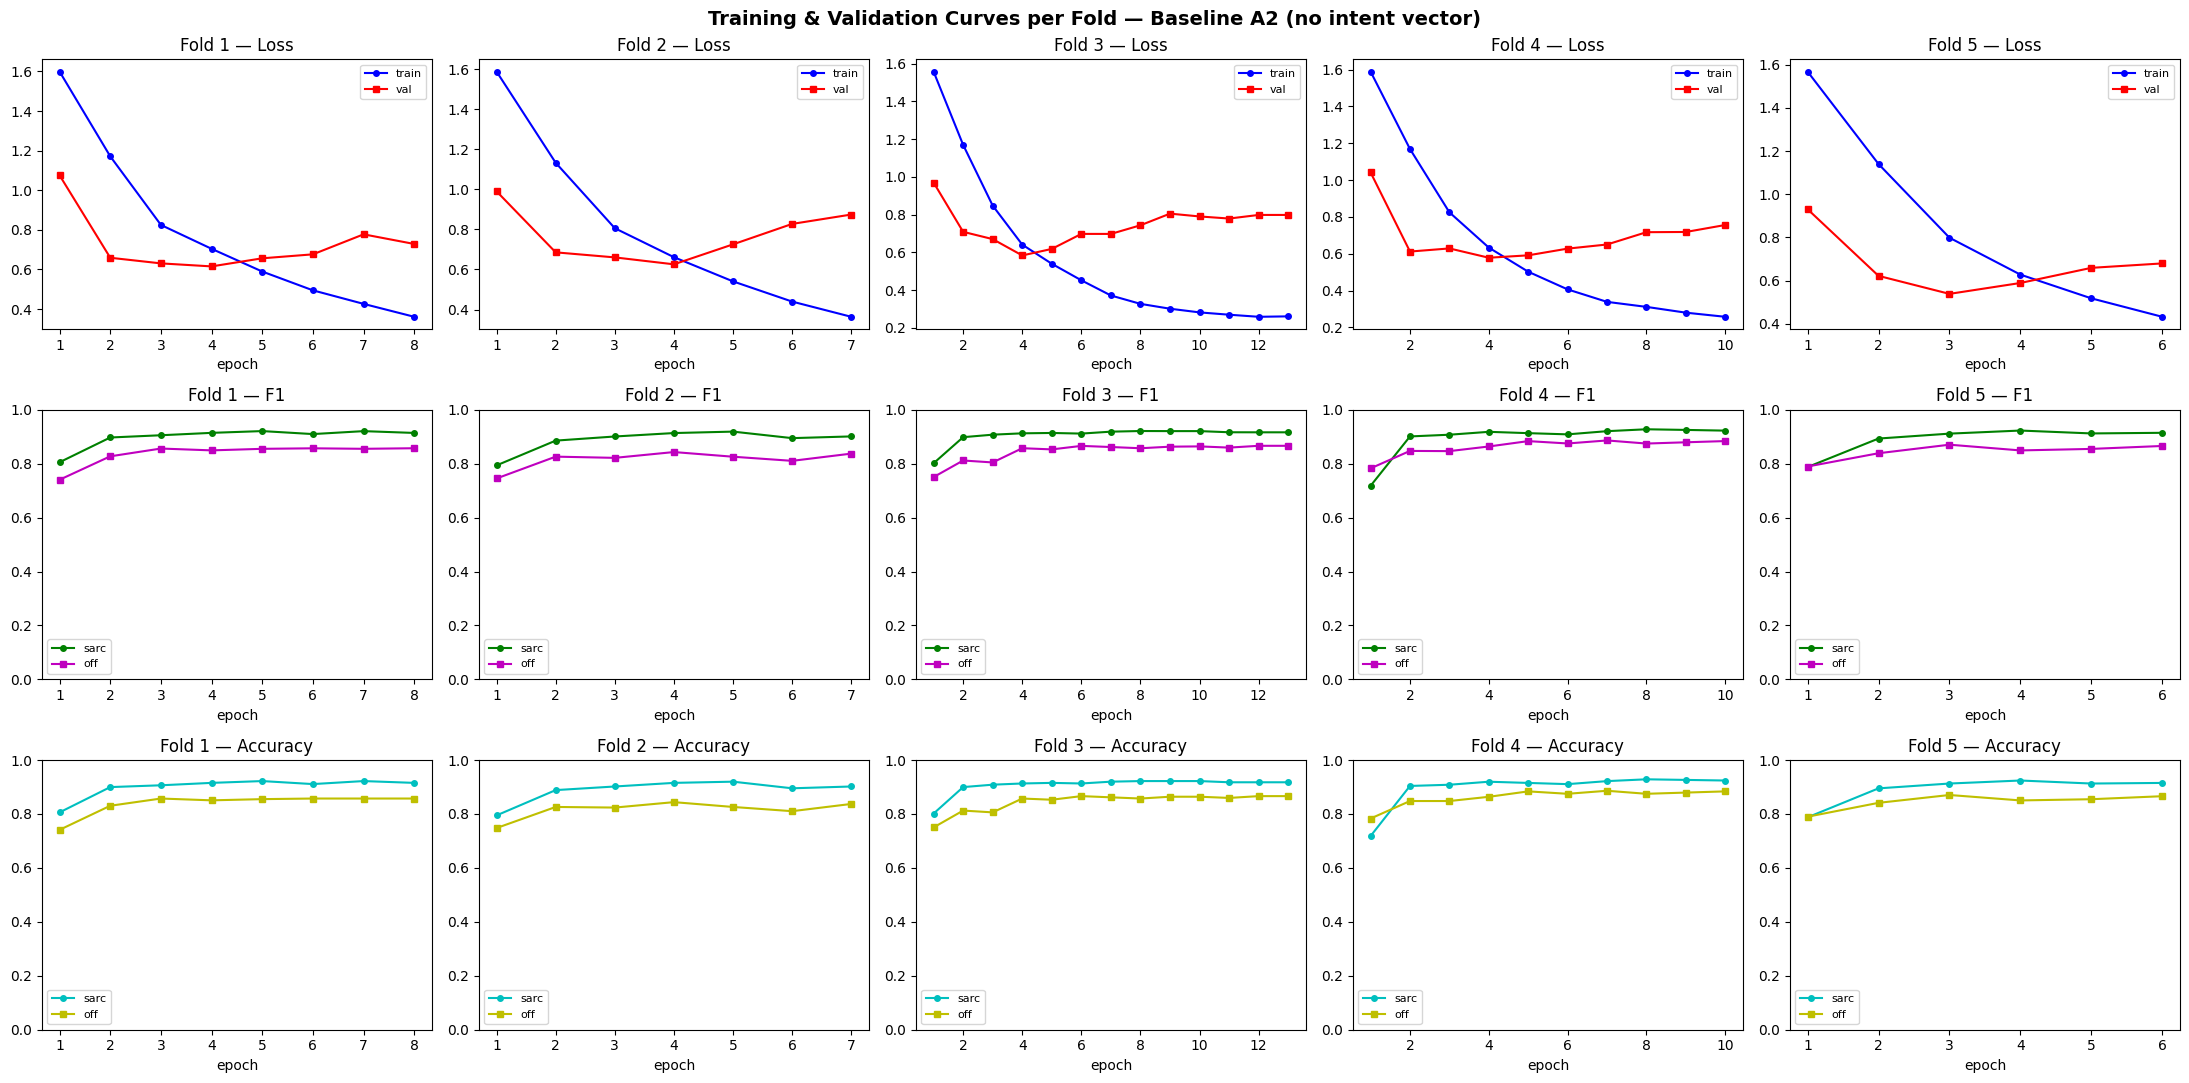

In [16]:
import matplotlib.pyplot as plt, matplotlib
matplotlib.rcParams["font.family"] = "DejaVu Sans"

hist = a2_cv["history"]; nF = len(hist)
fig, axes = plt.subplots(3, nF, figsize=(4.4*nF, 11), squeeze=False)
fig.suptitle("Training & Validation Curves per Fold — Baseline A2 (no intent vector)",
             fontsize=14, fontweight="bold")
for f, h in hist.items():
    ep = range(1, len(h["train_loss"])+1)
    axes[0][f].plot(ep, h["train_loss"], "b-o", ms=4, label="train"); axes[0][f].plot(ep, h["val_loss"], "r-s", ms=4, label="val")
    axes[0][f].set_title(f"Fold {f+1} — Loss"); axes[0][f].legend(fontsize=8); axes[0][f].set_xlabel("epoch")
    axes[1][f].plot(ep, h["sarc_f1"], "g-o", ms=4, label="sarc"); axes[1][f].plot(ep, h["off_f1"], "m-s", ms=4, label="off")
    axes[1][f].set_title(f"Fold {f+1} — F1"); axes[1][f].set_ylim(0,1); axes[1][f].legend(fontsize=8); axes[1][f].set_xlabel("epoch")
    axes[2][f].plot(ep, h["sarc_acc"], "c-o", ms=4, label="sarc"); axes[2][f].plot(ep, h["off_acc"], "y-s", ms=4, label="off")
    axes[2][f].set_title(f"Fold {f+1} — Accuracy"); axes[2][f].set_ylim(0,1); axes[2][f].legend(fontsize=8); axes[2][f].set_xlabel("epoch")
plt.tight_layout(); plt.savefig("training_curves.png", dpi=150, bbox_inches="tight"); plt.show()


## Section 13 — Hold-out Evaluation via 5-Fold **Ensemble** (not a single best fold)

The reported model averages the sigmoid probabilities of all A2 fold models. Because the
intent pathway is ablated, each fold model needs nothing but the tokenised
emoji-expanded text — there is no per-fold encoder to carry, and the ensemble is
leakage-free by construction (the hold-out split was made before any fitting).


In [17]:
# Section 13 — Hold-out Evaluation via 5-Fold Ensemble (Baseline A2)

REF_SEED      = CFG["ABLATION_SEED"]
A2_CHECKPOINT = os.path.join(CFG["RUN_DIR"], f"a2_run_seed{REF_SEED}.pt")

if 'a2_cv' not in dir():
    if os.path.exists(A2_CHECKPOINT):
        print(f"Loading A2 run checkpoint from {A2_CHECKPOINT}")
        checkpoint = torch.load(A2_CHECKPOINT, map_location="cpu", weights_only=False)
        a2_cv = {
            "models": [m.to("cpu") for m in checkpoint["models"]],
            "metrics": checkpoint["metrics"],
            "history": checkpoint["history"],
            "fold_indices": checkpoint["fold_indices"],
        }
        print("Checkpoint loaded successfully.")
    else:
        raise FileNotFoundError(f"No checkpoint found at {A2_CHECKPOINT}. Run Section 12 first.")

# --- Ensemble predictions from the A2 fold models ------------------------------
def ensemble_predict_single(models, raw_texts, max_len=None, batch_size=32, preprocess_fn=None):
    """Mean sigmoid prob across fold models. [A2] No intent encoder and no feature
    tensor: the forward pass receives token inputs only."""
    max_len = CFG["MAX_LEN"] if max_len is None else max_len
    pp = preprocess if preprocess_fn is None else preprocess_fn
    exp = [pp(t) for t in raw_texts]
    ps_sum = np.zeros(len(raw_texts)); po_sum = np.zeros(len(raw_texts))
    for m in models:
        m.to(DEVICE).eval()
        for i in range(0, len(raw_texts), batch_size):
            chunk = exp[i:i+batch_size]
            t = tokenizer(chunk, max_length=max_len, padding="max_length",
                          truncation=True, return_tensors="pt")
            with torch.no_grad():
                s, o = m(t["input_ids"].to(DEVICE), t["attention_mask"].to(DEVICE))
            ps_sum[i:i+batch_size] += torch.sigmoid(s).cpu().numpy()
            po_sum[i:i+batch_size] += torch.sigmoid(o).cpu().numpy()
        m.to("cpu")
    n = len(models)
    return ps_sum/n, po_sum/n

# --- Get test labels ---
sarc_true = df_test.sarcasm.values
off_true = df_test.offensive.values

# --- Generate ensemble predictions ---
sarc_prob, off_prob = ensemble_predict_single(a2_cv["models"], df_test.text.values)
sarc_pred, off_pred = (sarc_prob >= .5).astype(int), (off_prob >= .5).astype(int)

# --- Report function ---
def _report(tag, sp_prob, op_prob):
    spd, opd = (sp_prob>=.5).astype(int), (op_prob>=.5).astype(int)
    print("="*62); print(f"  HOLD-OUT TEST — {tag}"); print("="*62)
    print("\n── Sarcasm ──")
    print(classification_report(sarc_true, spd, target_names=["Non-Sarc","Sarc"], digits=4))
    print("── Offensive ──")
    print(classification_report(off_true, opd, target_names=["Non-Off","Off"], digits=4))
    yt = np.stack([sarc_true, off_true], 1); yp = np.stack([spd, opd], 1)
    print("── Multi-label ──")
    print(f"  Hamming Loss      : {hamming_loss(yt, yp):.4f}")
    print(f"  Exact Match Ratio : {np.all(yt==yp, axis=1).mean():.4f}")
    print(f"  Jaccard (samples) : {jaccard_score(yt, yp, average='samples'):.4f}")
    print(f"  Sarc MCC / AUC    : {matthews_corrcoef(sarc_true, spd):.4f} / {roc_auc_score(sarc_true, sp_prob):.4f}")
    print(f"  Off  MCC / AUC    : {matthews_corrcoef(off_true, opd):.4f} / {roc_auc_score(off_true, op_prob):.4f}")

_report("BASELINE A2 / 5-FOLD ENSEMBLE (unseen data)", sarc_prob, off_prob)


  HOLD-OUT TEST — BASELINE A2 / 5-FOLD ENSEMBLE (unseen data)

── Sarcasm ──
              precision    recall  f1-score   support

    Non-Sarc     0.8693    0.8895    0.8793       172
        Sarc     0.9132    0.8969    0.9050       223

    accuracy                         0.8937       395
   macro avg     0.8913    0.8932    0.8921       395
weighted avg     0.8941    0.8937    0.8938       395

── Offensive ──
              precision    recall  f1-score   support

     Non-Off     0.8776    0.8431    0.8600       204
         Off     0.8392    0.8743    0.8564       191

    accuracy                         0.8582       395
   macro avg     0.8584    0.8587    0.8582       395
weighted avg     0.8590    0.8582    0.8583       395

── Multi-label ──
  Hamming Loss      : 0.1241
  Exact Match Ratio : 0.7899
  Jaccard (samples) : 0.7456
  Sarc MCC / AUC    : 0.7845 / 0.9516
  Off  MCC / AUC    : 0.7171 / 0.9454


## Section 13b — Confusion Matrices & ROC Curves (hold-out)

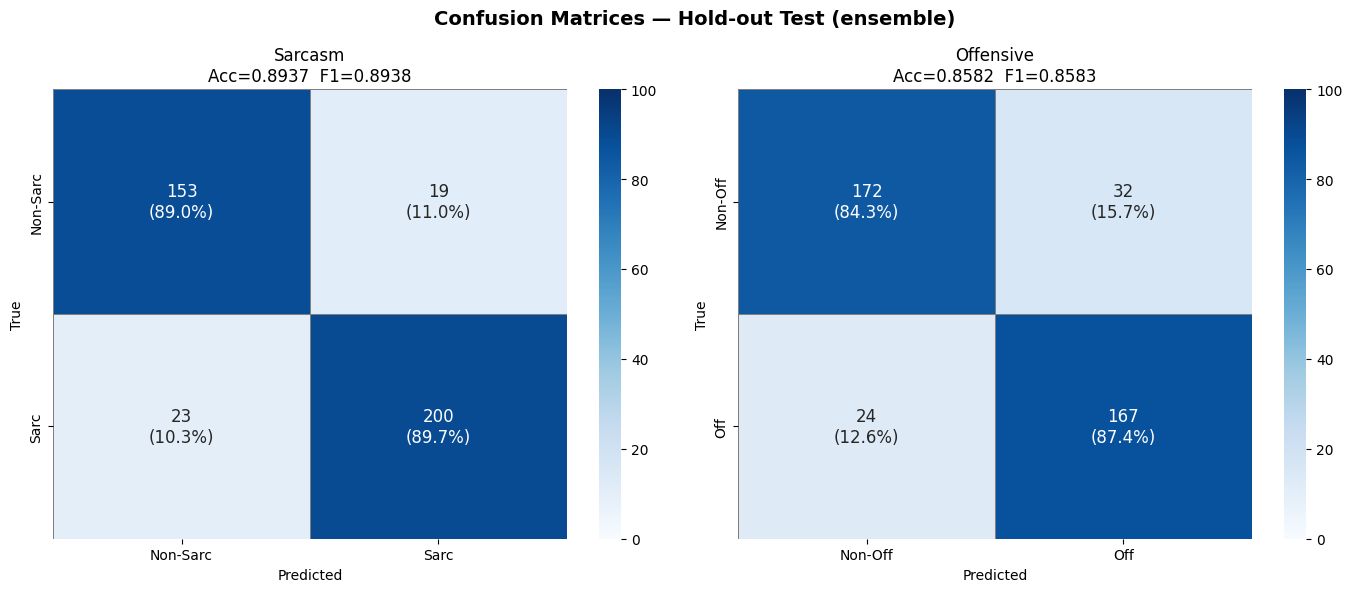

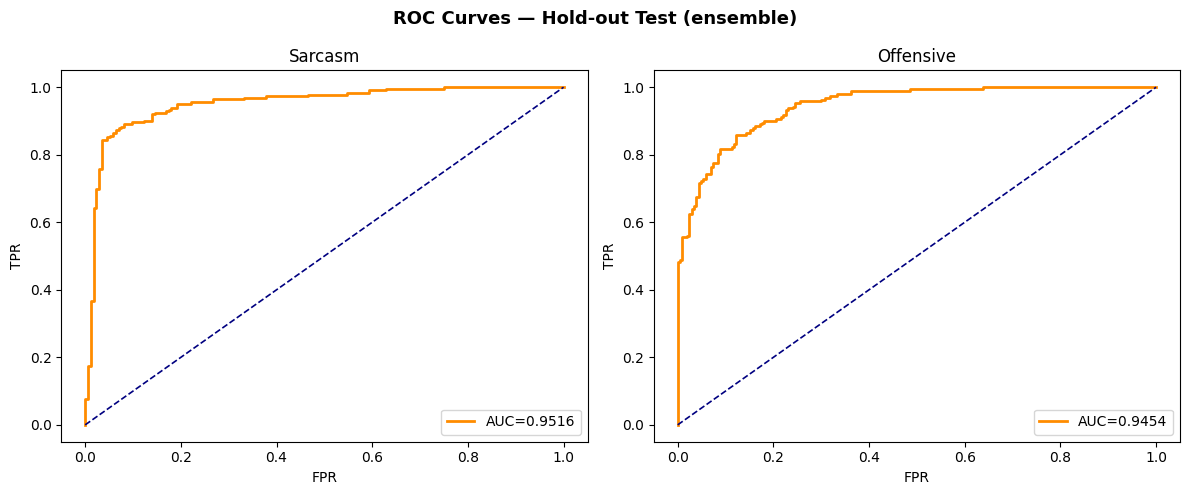

In [18]:
import seaborn as sns
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Confusion Matrices — Hold-out Test (ensemble)", fontsize=14, fontweight="bold")
for ax, (yt_, yp_, title, labels) in zip(axes, [
        (sarc_true, sarc_pred, "Sarcasm", ["Non-Sarc","Sarc"]),
        (off_true,  off_pred,  "Offensive", ["Non-Off","Off"])]):
    cm = confusion_matrix(yt_, yp_); pct = cm/cm.sum(1, keepdims=True)*100
    annot = np.array([[f"{cm[i,j]}\n({pct[i,j]:.1f}%)" for j in range(2)] for i in range(2)])
    sns.heatmap(pct, annot=annot, fmt="", cmap="Blues", xticklabels=labels, yticklabels=labels,
                ax=ax, vmin=0, vmax=100, linewidths=.5, linecolor="gray", annot_kws={"size":12})
    ax.set_title(f"{title}\nAcc={accuracy_score(yt_,yp_):.4f}  "
                 f"F1={f1_score(yt_,yp_,average='weighted',zero_division=0):.4f}")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.tight_layout(); plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight"); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("ROC Curves — Hold-out Test (ensemble)", fontsize=13, fontweight="bold")
for ax, (yt_, pb_, title) in zip(axes, [(sarc_true, sarc_prob, "Sarcasm"),
                                        (off_true, off_prob, "Offensive")]):
    fpr, tpr, _ = roc_curve(yt_, pb_); ax.plot(fpr, tpr, "darkorange", lw=2, label=f"AUC={auc(fpr,tpr):.4f}")
    ax.plot([0,1],[0,1],"navy",ls="--",lw=1.2); ax.set_title(f"{title}"); ax.legend(loc="lower right")
    ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
plt.tight_layout(); plt.savefig("roc_curves.png", dpi=150, bbox_inches="tight"); plt.show()

## Section 13c — Probability Calibration (reliability, ECE/Brier/NLL, temperature scaling)

A high macro-F1 doesn't guarantee the predicted probabilities are *trustworthy*. Here we
quantify calibration of the deployed **A2** ensemble on the hold-out test set —
Expected/Maximum Calibration Error (ECE/MCE), Brier score and NLL — and draw reliability
diagrams for both tasks. We then fit a single **temperature** per task on
**out-of-fold train/CV predictions** (leakage-free — the test set is never used to fit T)
and report the post-calibration improvement on test. Calibration is reported for the
positive-class probability P(y=1), the score that thresholding and the ROC curves in 13b
actually use. Removing the intent vector can shift confidence as well as accuracy, so
this section is worth reading alongside the reference run's numbers.


Fitted temperatures (on OOF train/CV, leakage-free): T_sarc=1.500  T_off=1.594

=== CALIBRATION ON HOLD-OUT TEST (Baseline A2) ===

── Sarcasm ──
  A2 raw        : ECE=0.0588 MCE=0.6092 Brier=0.0825 NLL=0.2995
  A2 +temp.     : ECE=0.0360 MCE=0.3777 Brier=0.0780 NLL=0.2729

── Offensive ──
  A2 raw        : ECE=0.0529 MCE=0.2502 Brier=0.0998 NLL=0.3180
  A2 +temp.     : ECE=0.0633 MCE=0.1175 Brier=0.0995 NLL=0.3306


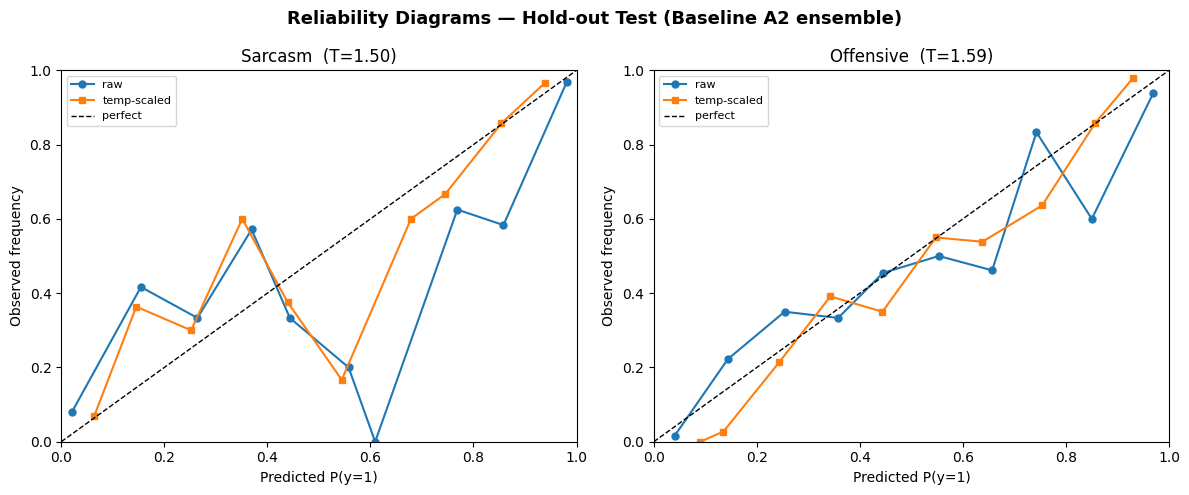

In [19]:
# Section 13c — Probability Calibration (reliability, ECE/Brier/NLL, temperature scaling)

from scipy.optimize import minimize_scalar

# ---- calibration metrics (positive-class P(y=1)) ------------------------------
def calib_bins(y, p, n_bins=10):
    y = np.asarray(y); p = np.asarray(p)
    edges = np.linspace(0, 1, n_bins + 1)
    conf = np.full(n_bins, np.nan); acc = np.full(n_bins, np.nan); wt = np.zeros(n_bins)
    idx = np.clip(np.digitize(p, edges[1:-1]), 0, n_bins - 1)
    for b in range(n_bins):
        m = idx == b
        if m.any():
            conf[b] = p[m].mean(); acc[b] = y[m].mean(); wt[b] = m.mean()
    return edges, conf, acc, wt

def calib_scores(y, p, n_bins=10):
    _, conf, acc, wt = calib_bins(y, p, n_bins)
    ok = ~np.isnan(conf)
    ece = float(np.sum(wt[ok] * np.abs(acc[ok] - conf[ok])))
    mce = float(np.max(np.abs(acc[ok] - conf[ok]))) if ok.any() else float("nan")
    y = np.asarray(y); pc = np.clip(np.asarray(p), 1e-6, 1 - 1e-6)
    brier = float(np.mean((pc - y) ** 2))
    nll = float(-np.mean(y * np.log(pc) + (1 - y) * np.log(1 - pc)))
    return {"ECE": ece, "MCE": mce, "Brier": brier, "NLL": nll}

# ---- temperature scaling on ensemble probabilities ----------------------------
def _logit(p):
    p = np.clip(p, 1e-6, 1 - 1e-6)
    return np.log(p / (1 - p))

def _apply_T(p, T):
    return 1.0 / (1.0 + np.exp(-_logit(p) / T))

def _fit_T(p_val, y_val):
    z = _logit(p_val)
    def nll(T):
        q = np.clip(1.0 / (1.0 + np.exp(-z / T)), 1e-6, 1 - 1e-6)
        return -np.mean(y_val * np.log(q) + (1 - y_val) * np.log(1 - q))
    return float(minimize_scalar(nll, bounds=(0.05, 10.0), method="bounded").x)

# ---- leakage-free OOF validation probs from the A2 fold models -----------------
# Each pool example is scored by the fold model for which it was in the VALIDATION
# split -> genuine held-out predictions, no test data used.
oof_sarc = np.full(len(df_trainval), np.nan)
oof_off  = np.full(len(df_trainval), np.nan)
for f, (a, b) in enumerate(a2_cv["fold_indices"]):
    ps, po = ensemble_predict_single([a2_cv["models"][f]], df_trainval.text.values[b])
    oof_sarc[b] = ps; oof_off[b] = po
y_sarc_tv, y_off_tv = df_trainval.sarcasm.values, df_trainval.offensive.values

T_sarc = _fit_T(oof_sarc, y_sarc_tv)
T_off  = _fit_T(oof_off,  y_off_tv)
print(f"Fitted temperatures (on OOF train/CV, leakage-free): "
      f"T_sarc={T_sarc:.3f}  T_off={T_off:.3f}\n")

# ---- calibrate the A2 test ensemble (same model family as the OOF fit) --------
sarc_prob_cal = _apply_T(sarc_prob, T_sarc)
off_prob_cal  = _apply_T(off_prob,  T_off)

print("=== CALIBRATION ON HOLD-OUT TEST (Baseline A2) ===")
cal_rows = []

for tag, yt, praw, pcal in [("Sarcasm", sarc_true, sarc_prob, sarc_prob_cal),
                            ("Offensive", off_true, off_prob, off_prob_cal)]:
    raw = calib_scores(yt, praw)
    cal = calib_scores(yt, pcal)

    print(f"\n── {tag} ──")
    print(f"  A2 raw        : ECE={raw['ECE']:.4f} MCE={raw['MCE']:.4f} "
          f"Brier={raw['Brier']:.4f} NLL={raw['NLL']:.4f}")
    print(f"  A2 +temp.     : ECE={cal['ECE']:.4f} MCE={cal['MCE']:.4f} "
          f"Brier={cal['Brier']:.4f} NLL={cal['NLL']:.4f}")

    cal_rows += [{"task": tag, "variant": "a2_raw", **raw},
                 {"task": tag, "variant": "a2_temp", **cal}]

if cal_rows:
    calib_df = pd.DataFrame(cal_rows)
    calib_df.to_csv(os.path.join(CFG["RUN_DIR"], "a2_calibration.csv"), index=False)

# ---- reliability diagrams (raw vs temperature-scaled) -------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Reliability Diagrams — Hold-out Test (Baseline A2 ensemble)",
             fontsize=13, fontweight="bold")
for ax, (tag, yt, praw, pcal) in zip(axes, [("Sarcasm", sarc_true, sarc_prob, sarc_prob_cal),
                                            ("Offensive", off_true, off_prob, off_prob_cal)]):
    for p, lab, style in [(praw, "raw", "o-"), (pcal, "temp-scaled", "s-")]:
        _, conf, acc, _ = calib_bins(yt, p, 10); ok = ~np.isnan(conf)
        ax.plot(conf[ok], acc[ok], style, ms=5, label=lab)
    ax.plot([0, 1], [0, 1], "k--", lw=1, label="perfect")
    ax.set_title(f"{tag}  (T={T_sarc if tag=='Sarcasm' else T_off:.2f})")
    ax.set_xlabel("Predicted P(y=1)"); ax.set_ylabel("Observed frequency")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.legend(loc="upper left", fontsize=8)
plt.tight_layout(); plt.savefig("calibration_reliability.png", dpi=150, bbox_inches="tight"); plt.show()


## Section 13d — Robustness to Input Perturbations

We probe how stable **Baseline A2** is under realistic, mostly meaning-preserving
perturbations of the hold-out inputs, all evaluated with the A2 ensemble on identical
labels:

* **emoji_drop** — all emojis removed. In A2 this degrades the *text* pathway only
  (there is no intent vector left to lose), so the drop measures how much of the emoji
  signal survives purely as expanded Bangla phrases — the crux of the A2 hypothesis.
* **emoji_swap_in** — one emoji swapped for a sibling in the *same* intent cluster
  (meaning-preserving): predictions should be **stable** (low flip-rate, small ΔF1).
* **emoji_swap_cross** — one emoji swapped for a *different*-cluster emoji (distractor):
  measures spurious sensitivity.
* **emoji_repeat** — existing emojis tripled (🤣→🤣🤣🤣): intensity robustness. Note that
  in the reference model repetition also moved the *density* feature; in A2 it can only
  act through repeated phrase tokens.
* **char_typo** — character-level noise on Bangla text with emojis preserved: text robustness.

For each we report macro-F1 per task, Δ vs clean, and the **prediction flip-rate** (share
of examples whose predicted label changed vs clean), overall and on emoji-bearing rows.
All perturbations are seeded for reproducibility.


=== ROBUSTNESS TO INPUT PERTURBATIONS (Baseline A2 ensemble, hold-out) ===
    perturbation  sarc_macroF1  off_macroF1   Δsarc    Δoff  flip%_all  flip%_emoji_rows
           clean        0.8921       0.8582  0.0000  0.0000     0.0000            0.0000
      emoji_drop        0.6783       0.7836 -0.2139 -0.0746    37.4684           37.9487
   emoji_swap_in        0.8896       0.8580 -0.0025 -0.0002     8.8608            8.9744
emoji_swap_cross        0.6870       0.7544 -0.2051 -0.1038    38.9873           39.4872
 emoji_repeat_x3        0.8280       0.7798 -0.0641 -0.0784    26.0759           26.4103
       char_typo        0.8869       0.8532 -0.0053 -0.0050     9.8734            9.2308


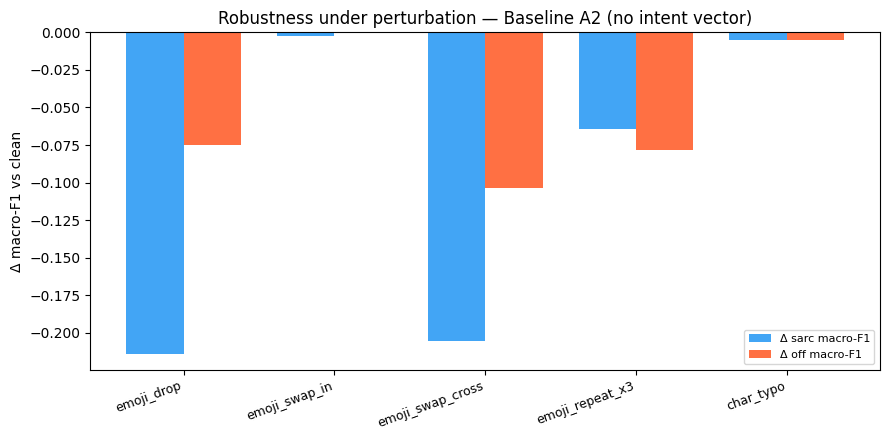


Reading the table: in A2 every perturbation acts through the TEXT pathway alone,
so emoji_drop isolates how much emoji signal survives as expanded Bangla phrases;
emoji_swap_in / char_typo should still show SMALL ΔF1 + low flip-rate (meaning-preserving);
emoji_swap_cross probes spurious sensitivity to a distractor emoji.


In [20]:
# Section 13d — Robustness to Input Perturbations (Baseline A2)

rob_rng = random.Random(SEED)

def perturb_emoji_drop(t):   return strip_emojis(t)
def perturb_emoji_swap_in(t): return augment_emoji_substitution(t, p=1.0, rng=rob_rng)  # in-cluster

def perturb_emoji_swap_cross(t):
    chars = list(str(t)); pos = [i for i, c in enumerate(chars) if c in EMOJI_TO_CLUSTER]
    if not pos: return t
    i = rob_rng.choice(pos); cur = chars[i]
    same = set(next((cl for cl in CLUSTERS if cur in cl), []))
    other = [c for cl in CLUSTERS for c in cl if c not in same]
    if other: chars[i] = rob_rng.choice(other)
    return "".join(chars)

def perturb_emoji_repeat(t, k=3):
    return "".join(c * (k if c in emojilib.EMOJI_DATA else 1) for c in str(t))

def perturb_typo(t, p=0.08):
    out = []
    for c in str(t):
        if c in emojilib.EMOJI_DATA: out.append(c); continue
        r = rob_rng.random()
        if r < p * 0.5:      continue                 # drop char
        elif r < p:          out.append(c); out.append(c)   # duplicate char
        else:                out.append(c)
    return "".join(out)

def eval_perturbation(texts):
    # [A2] ensemble_predict_single takes token inputs only — no encoders argument.
    ps, po = ensemble_predict_single(a2_cv["models"], list(texts))
    return {"sarc_pred": (ps >= .5).astype(int), "off_pred": (po >= .5).astype(int),
            "sarc_f1": f1_score(sarc_true, (ps >= .5).astype(int), average="macro", zero_division=0),
            "off_f1":  f1_score(off_true,  (po >= .5).astype(int), average="macro", zero_division=0)}

clean_texts = list(df_test.text.values)
has_emoji   = np.array([len(extract_emojis(t)) > 0 for t in clean_texts])
base        = eval_perturbation(clean_texts)
base_sp, base_op = base["sarc_pred"], base["off_pred"]

PERTS = [("emoji_drop",        [perturb_emoji_drop(t)       for t in clean_texts]),
         ("emoji_swap_in",     [perturb_emoji_swap_in(t)    for t in clean_texts]),
         ("emoji_swap_cross",  [perturb_emoji_swap_cross(t) for t in clean_texts]),
         ("emoji_repeat_x3",   [perturb_emoji_repeat(t)     for t in clean_texts]),
         ("char_typo",         [perturb_typo(t)             for t in clean_texts])]

rows = [{"perturbation": "clean", "sarc_macroF1": base["sarc_f1"], "off_macroF1": base["off_f1"],
         "Δsarc": 0.0, "Δoff": 0.0, "flip%_all": 0.0, "flip%_emoji_rows": 0.0}]
for name, texts in PERTS:
    r = eval_perturbation(texts)
    changed = (r["sarc_pred"] != base_sp) | (r["off_pred"] != base_op)
    flip_all = changed.mean() * 100
    flip_em  = changed[has_emoji].mean() * 100 if has_emoji.any() else float("nan")
    rows.append({"perturbation": name, "sarc_macroF1": r["sarc_f1"], "off_macroF1": r["off_f1"],
                 "Δsarc": r["sarc_f1"] - base["sarc_f1"], "Δoff": r["off_f1"] - base["off_f1"],
                 "flip%_all": flip_all, "flip%_emoji_rows": flip_em})

rob_df = pd.DataFrame(rows)
print("=== ROBUSTNESS TO INPUT PERTURBATIONS (Baseline A2 ensemble, hold-out) ===")
print(rob_df.round(4).to_string(index=False))
rob_df.to_csv(os.path.join(CFG["RUN_DIR"], "a2_robustness.csv"), index=False)

# ---- ΔF1 bar plot -------------------------------------------------------------
plot_df = rob_df[rob_df.perturbation != "clean"]
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(plot_df)); w = 0.38
ax.bar(x - w/2, plot_df["Δsarc"], w, label="Δ sarc macro-F1", color="#42a5f5")
ax.bar(x + w/2, plot_df["Δoff"],  w, label="Δ off macro-F1",  color="#ff7043")
ax.axhline(0, color="k", lw=.7)
ax.set_xticks(x); ax.set_xticklabels(plot_df["perturbation"], rotation=20, ha="right", fontsize=9)
ax.set_ylabel("Δ macro-F1 vs clean"); ax.set_title("Robustness under perturbation — Baseline A2 (no intent vector)")
ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig("robustness_delta_f1.png", dpi=150, bbox_inches="tight"); plt.show()

print("\nReading the table: in A2 every perturbation acts through the TEXT pathway alone,")
print("so emoji_drop isolates how much emoji signal survives as expanded Bangla phrases;")
print("emoji_swap_in / char_typo should still show SMALL ΔF1 + low flip-rate (meaning-preserving);")
print("emoji_swap_cross probes spurious sensitivity to a distractor emoji.")


## Section 14 — Explainability: LIME on the Model's Real (Preprocessed) Input

LIME is run on the **preprocessed** text — the exact emoji-expanded string the model
consumes — so attributions reflect the deployed pipeline. Each emoji phrase is kept as
**one atomic token** (via a surrogate encoding), and emoji vs word tokens stay cleanly
separable for the quantitative test in Section 19.

**A2 simplification:** the reference notebook had to *freeze* the intent vector during
perturbation (it cannot be re-derived once emojis are masked), which meant LIME explained
only the text-encoder pathway of a two-pathway model. In A2 the text encoder is the
**only** pathway, so the explanation is complete and unconditional — every attribution the
model relies on is visible to LIME. That makes the emoji-token weights here directly
comparable to the reference run's while being a strictly more faithful account of *this*
model.


In [21]:
from lime.lime_text import LimeTextExplainer

# ---- Diagnostic-only intent encoder -------------------------------------------
# NOT part of the A2 model: nothing below feeds it into a forward pass. It is fitted on
# the train/CV pool only (never on test labels) purely so Sections 17 and 18 can score
# emoji ambiguity and draw the emoji-intent space — i.e. so we can still characterise the
# signal that A2 deliberately throws away.
explain_encoder = EmojiIntentEncoder().fit(
    df_trainval.text.values, df_trainval.sarcasm.values, df_trainval.offensive.values)

# --- LIME operates on PREPROCESSED text (the exact format the model was trained on) ---
# Emoji phrases are multi-word (e.g. "[ব্যঙ্গাত্মক হাসি]").  To keep each phrase a single,
# perturbable LIME token, internal spaces are swapped for NUL ("\x00") to form a
# "surrogate" string; the predict_fn restores them before tokenising for the model.
def _units(exp_text):
    """Split preprocessed text into units; bracketed emoji phrases stay atomic."""
    toks, units, buf = exp_text.split(" "), [], []
    for t in toks:
        if buf:
            buf.append(t)
            if t.endswith("]"): units.append(" ".join(buf)); buf = []
        elif t.startswith("[") and not t.endswith("]"):
            buf = [t]
        else:
            units.append(t)
    if buf: units.append(" ".join(buf))
    return [u for u in units if u]

def to_surrogate(exp_text):
    return " ".join(u.replace(" ", "\x00") for u in _units(exp_text))

def is_emoji_token(tok):
    """Emoji-phrase tokens are the bracketed units produced by expand_emojis()."""
    return tok.strip().startswith("[")

def make_lime_predict_fn_pre(models, task="sarcasm"):
    """LIME predict_fn over surrogate (preprocessed) strings.

    [A2] There is no intent vector to hold fixed — the text encoder is the model's only
    pathway, so LIME explains the whole model rather than one branch of it."""
    def predict_fn(surrogate_texts):
        real = [s.replace("\x00", " ") for s in surrogate_texts]
        enc = tokenizer(real, max_length=CFG["MAX_LEN"], padding="max_length",
                        truncation=True, return_tensors="pt")
        prob = np.zeros(len(real))
        for m in models:
            m.to(DEVICE).eval()
            with torch.no_grad():
                s, o = m(enc["input_ids"].to(DEVICE), enc["attention_mask"].to(DEVICE))
            prob += torch.sigmoid(s if task == "sarcasm" else o).cpu().numpy(); m.to("cpu")
        prob /= len(models)
        return np.c_[1-prob, prob]
    return predict_fn

# --- Version-robust LIME explainer construction --------------------------------
# Some installed lime builds accept `split_expr`/`bow` as __init__ kwargs and
# some do NOT (that mismatch raised: TypeError ... unexpected keyword 'split_expr').
# We introspect the signature, pass only what is supported, then set the
# tokenisation attributes directly (explain_instance reads them off `self` when it
# builds the IndexedString), so whitespace-only splitting holds on any lime version.
def _make_lime_text_explainer(class_names):
    import inspect
    _params = inspect.signature(LimeTextExplainer.__init__).parameters
    _kwargs = {"class_names": class_names}
    if "split_expr" in _params: _kwargs["split_expr"] = r"\s+"
    if "bow"        in _params: _kwargs["bow"]        = True
    _explainer = LimeTextExplainer(**_kwargs)
    _explainer.split_expr = r"\s+"   # NUL-joined emoji phrases stay atomic (NUL is not \s)
    _explainer.bow        = True
    _explainer.char_level = False
    return _explainer

def lime_explain_pre(raw_text, task, class_names, models=None, num_samples=None, num_features=15):
    models = a2_cv["models"] if models is None else models
    num_samples = CFG["LIME_SAMPLES"] if num_samples is None else num_samples
    exp_text  = preprocess(raw_text)
    surrogate = to_surrogate(exp_text)
    fn        = make_lime_predict_fn_pre(models, task=task)
    explainer = _make_lime_text_explainer(class_names)
    exp = explainer.explain_instance(surrogate, fn, num_features=num_features,
                                     num_samples=num_samples, labels=[1])
    return exp

def lime_features(exp):
    """Return [(readable_token, weight)] with NUL restored to space."""
    return [(feat.replace("\x00", " "), w) for feat, w in exp.as_list(label=1)]

# choose an example WITH emojis from the test set
cand = [i for i in range(len(df_test)) if extract_emojis(df_test.text.iloc[i])]
sidx = cand[0]
raw_example = df_test.text.iloc[sidx]
print(f"Explaining: {raw_example}")
print(f"  preprocessed: {preprocess(raw_example)}")
print(f"  truth: Sarcasm={sarc_true[sidx]}, Offensive={off_true[sidx]}")


Explaining: এই চেহারা নিয়ে চান্স পেল কিভাবে 🙄🙄
  preprocessed: এই চেহারা নিয়ে চান্স পেল কিভাবে [চোখ ঘোরানো] [চোখ ঘোরানো]
  truth: Sarcasm=0, Offensive=1



LIME — sarcasm:
  🔤 এই                           -0.2882
  🔤 খ                            +0.1016
  🔤 হ                            -0.0795
  🔤 য                            -0.0777
  🔤 প                            +0.0690
  🔤 ভ                            +0.0622
  🔤 ব                            -0.0446
  🔤 ল                            +0.0384
  🔤 র                            +0.0364
  🔤 স                            +0.0291
  🔤 ন                            +0.0263
  🔤 চ                            +0.0116
  🔤 ঘ                            +0.0109
  🔤 ক                            +0.0089


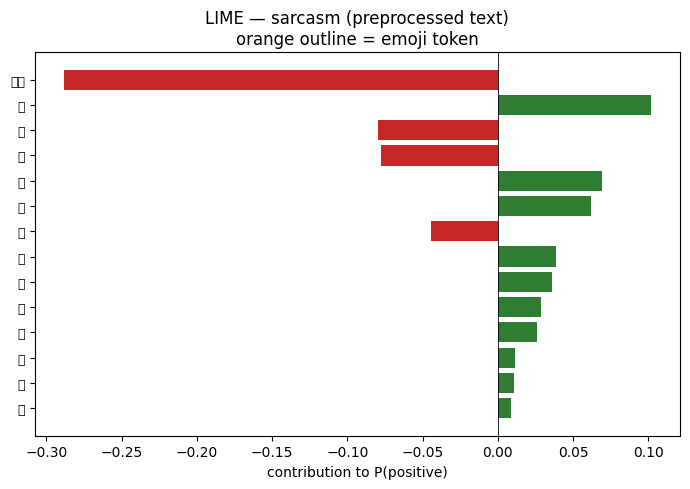


LIME — offensive:
  🔤 ন                            +0.1879
  🔤 চ                            +0.1838
  🔤 এই                           +0.1573
  🔤 ভ                            -0.1002
  🔤 ঘ                            +0.0716
  🔤 ক                            +0.0573
  🔤 য                            +0.0498
  🔤 খ                            -0.0449
  🔤 প                            -0.0405
  🔤 হ                            +0.0366
  🔤 ল                            +0.0245
  🔤 র                            +0.0218
  🔤 স                            -0.0092
  🔤 ব                            -0.0039


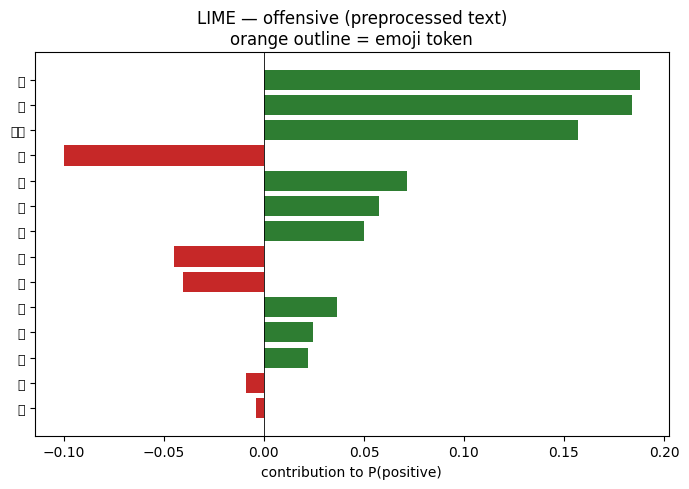

In [22]:
for task, names, png in [("sarcasm", ["Non-Sarc","Sarc"], "lime_sarcasm.png"),
                         ("offensive", ["Non-Off","Off"], "lime_offensive.png")]:
    exp = lime_explain_pre(raw_example, task, names)
    feats = lime_features(exp)
    print(f"\nLIME — {task}:")
    for feat, w in feats:
        print(f"  {'😀' if is_emoji_token(feat) else '🔤'} {feat:<28} {w:+.4f}")
    # readable horizontal bar (green=+, red=-), emoji tokens outlined
    labels = [f for f, _ in feats][::-1]; vals = [w for _, w in feats][::-1]
    colors = ["#2e7d32" if w >= 0 else "#c62828" for w in vals]
    edges  = ["#ff7043" if is_emoji_token(f) else "none" for f in labels]
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.barh(range(len(vals)), vals, color=colors, edgecolor=edges, linewidth=2)
    ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels, fontsize=9)
    ax.axvline(0, color="k", lw=.6); ax.set_title(f"LIME — {task} (preprocessed text)\norange outline = emoji token")
    ax.set_xlabel("contribution to P(positive)")
    plt.tight_layout(); plt.savefig(png, dpi=150, bbox_inches="tight"); plt.show()

## Section 14b — Emoji vs Word Contribution (single example)

For one representative example we contrast the total |LIME weight| carried by emoji tokens vs word tokens, for each task. The **population-level** hypothesis test that emojis contribute more than words (paired *t*-test + Wilcoxon over many examples) is deferred to Section 19.

sarcasm: emoji-mass=0.0000  word-mass=0.8996  emoji-share=0.0%
offensive: emoji-mass=0.0000  word-mass=0.9964  emoji-share=0.0%


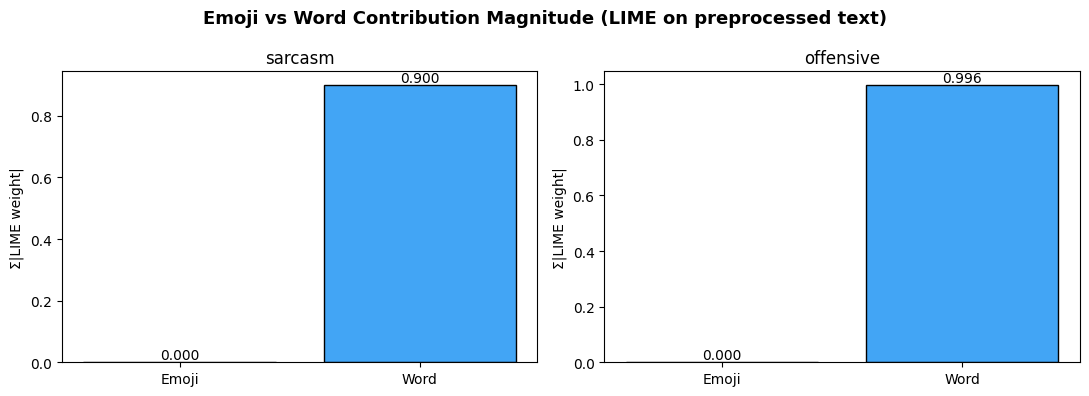


Note: the population-level 'emojis matter' t-test (many examples) is in Section 19.


In [23]:
def emoji_word_split(exp):
    em, wd = [], []
    for feat, w in lime_features(exp):
        (em if is_emoji_token(feat) else wd).append((feat, w))
    return em, wd

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle("Emoji vs Word Contribution Magnitude (LIME on preprocessed text)", fontsize=13, fontweight="bold")
for ax, (task, names) in zip(axes, [("sarcasm",["Non-Sarc","Sarc"]),("offensive",["Non-Off","Off"])]):
    exp = lime_explain_pre(raw_example, task, names)
    em, wd = emoji_word_split(exp)
    vals = [sum(abs(w) for _, w in em), sum(abs(w) for _, w in wd)]
    bars = ax.bar(["Emoji","Word"], vals, color=["#ff7043","#42a5f5"], edgecolor="k")
    ax.set_title(task); ax.set_ylabel("Σ|LIME weight|")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1e-3, f"{v:.3f}", ha="center", va="bottom")
    share = vals[0]/max(sum(vals),1e-9)*100
    print(f"{task}: emoji-mass={vals[0]:.4f}  word-mass={vals[1]:.4f}  emoji-share={share:.1f}%")
plt.tight_layout(); plt.savefig("lime_emoji_vs_word.png", dpi=150, bbox_inches="tight"); plt.show()
print("\nNote: the population-level 'emojis matter' t-test (many examples) is in Section 19.")

## Section 15 — Robust Inference (`predict_text`) + Interactive Prompt

A single reusable `predict_text` with full **input validation and error handling** (empty,
over-long, non-Bangla, emoji-only, tokenizer/model failure) that returns a status field
instead of raising. In A2 inference is a one-step pipeline — preprocess, tokenise,
ensemble — because no intent encoder has to be carried alongside the weights. The
interactive prompt is **enabled by default** and guarded so "Run all" in a non-interactive
kernel skips it cleanly.

*"Is it deployment-ready?"* Malformed input degrades gracefully to a labelled
warning/error rather than crashing the pipeline.


In [24]:
BANGLA_RANGE = range(0x0980, 0x0A00)   # Bengali Unicode block
def _has_bangla(t): return any(ord(ch) in BANGLA_RANGE for ch in str(t))

def predict_text(raw_text, models=None, thr_s=0.5, thr_o=0.5, max_chars=2000):
    """Robust single-text inference for Baseline A2. Returns a dict; on bad input
    returns an 'error'/'warning' field instead of raising.

    [A2] No `encoder` argument: the model consumes tokenised emoji-expanded text only."""
    models = a2_cv["models"] if models is None else models
    try:
        # --- input validation ---------------------------------------------------
        if raw_text is None or not str(raw_text).strip():
            return {"error": "empty_input", "label": "⛔ EMPTY INPUT",
                    "p_sarcasm": None, "p_offensive": None}
        raw_text = str(raw_text)
        warning = None
        if len(raw_text) > max_chars:                      # very long text -> truncate
            raw_text = raw_text[:max_chars]; warning = f"truncated_to_{max_chars}_chars"
        if not _has_bangla(raw_text):                      # non-Bangla -> still predict, but flag
            warning = (warning + "; " if warning else "") + "no_bangla_characters_detected"

        # --- forward pass (guarded) --------------------------------------------
        exp   = preprocess(raw_text)
        enc   = tokenizer(exp, max_length=CFG["MAX_LEN"], padding="max_length",
                          truncation=True, return_tensors="pt")
        sp = op = 0.0
        for m in models:
            m.to(DEVICE).eval()
            with torch.no_grad():
                s, o = m(enc["input_ids"].to(DEVICE), enc["attention_mask"].to(DEVICE))
            sp += torch.sigmoid(s).item(); op += torch.sigmoid(o).item(); m.to("cpu")
        sp /= len(models); op /= len(models)
    except Exception as e:                                  # tokenizer / model / any failure
        return {"error": f"{type(e).__name__}: {e}", "label": "⛔ INFERENCE ERROR",
                "p_sarcasm": None, "p_offensive": None}

    is_s, is_o = sp >= thr_s, op >= thr_o
    label = ("⚠️ SARCASTIC + OFFENSIVE" if is_s and is_o else
             "😏 SARCASTIC (not offensive)" if is_s else
             "😡 OFFENSIVE (not sarcastic)" if is_o else "✅ NEITHER")
    out = {"raw": raw_text, "expanded": exp, "emojis": extract_emojis(raw_text),
           "p_sarcasm": round(sp, 4), "p_offensive": round(op, 4), "label": label}
    if warning: out["warning"] = warning
    return out

# smoke tests, incl. edge cases (empty / non-Bangla / emoji-only)
for t in ["সে অনেক ভদ্র 🤣", "তুমি একটা গাধা 😡",
          "করিম এর বুদ্ধি প্রশংসনীয় 🤣 😡", "আজকের আবহাওয়া সুন্দর।",
          "", "hello world 🙂", "🤣🤣🤣"]:
    r = predict_text(t)
    tag = r.get("error") or r.get("warning") or ""
    print(f"{r['label']:<32} P(sarc)={r['p_sarcasm']} P(off)={r['p_offensive']} | {t!r} {('['+tag+']') if tag else ''}")


😏 SARCASTIC (not offensive)      P(sarc)=0.9879 P(off)=0.1516 | 'সে অনেক ভদ্র 🤣' 
😡 OFFENSIVE (not sarcastic)      P(sarc)=0.0149 P(off)=0.9859 | 'তুমি একটা গাধা 😡' 
⚠️ SARCASTIC + OFFENSIVE         P(sarc)=0.974 P(off)=0.9532 | 'করিম এর বুদ্ধি প্রশংসনীয় 🤣 😡' 
😏 SARCASTIC (not offensive)      P(sarc)=0.5623 P(off)=0.0253 | 'আজকের আবহাওয়া সুন্দর।' 
⛔ EMPTY INPUT                    P(sarc)=None P(off)=None | '' [empty_input]
✅ NEITHER                        P(sarc)=0.1265 P(off)=0.0325 | 'hello world 🙂' [no_bangla_characters_detected]
😏 SARCASTIC (not offensive)      P(sarc)=0.9823 P(off)=0.3572 | '🤣🤣🤣' [no_bangla_characters_detected]


In [25]:
# Interactive inference — ENABLED by default. The guard makes "Run all" safe:
# in a non-interactive kernel input() raises, and we skip gracefully.
import sys
ENABLE_INTERACTIVE = True
if ENABLE_INTERACTIVE:
    interactive_ok = hasattr(sys, "stdin") and sys.stdin is not None and sys.stdin.isatty()
    if not interactive_ok:
        print("Interactive prompt is ENABLED but stdin is non-interactive "
              "(e.g. 'Run all' / batch). Skipping the prompt; call predict_text('...') directly.")
    else:
        try:
            txt = input("Enter Bangla text (with/without emojis), or press Enter to skip: ").strip()
            if txt:
                r = predict_text(txt)
                print(r["label"], "| P(sarc)=", r["p_sarcasm"], "P(off)=", r["p_offensive"],
                      ("| ⚠ " + r["warning"]) if r.get("warning") else "")
        except (EOFError, KeyboardInterrupt):
            print("No interactive input available — skipped.")

Interactive prompt is ENABLED but stdin is non-interactive (e.g. 'Run all' / batch). Skipping the prompt; call predict_text('...') directly.


## Section 16 — Task Relationship & the A2 Controlled Comparison

We quantify the sarcasm–offensive relationship (χ², φ) and report its **direction**: the
association is **negative** (sarcastic texts are *less* often offensive), which still
justifies joint modelling and is a signal the cross-stitch layer can exploit.

The ablation ladder is then run **on identical folds and training budget**, with all three
A2-family arms sharing the same architecture except for the factor being removed:

| Arm | Emoji text | Intent vector | Cross-stitch |
|---|---|---|---|
| **A0** No-emoji (text only) | ✗ | ✗ | ✗ |
| **A1** A2 without cross-stitch | ✓ | ✗ | ✗ |
| **A2** *this baseline* | ✓ | ✗ | ✓ |
| **Full** reference run | ✓ | ✓ | ✓ |

**The A2 → Full contrast is the hypothesis of record**: both arms see exactly the same
emoji-expanded text, the same folds, the same seed and the same hyper-parameters, and
differ *only* in whether the leakage-free propensity vector is concatenated to `[CLS]`. A
significant Full > A2 gap means intent statistics carry signal the tokenizer cannot
recover from emoji phrases; a null result means emoji→text expansion already captures it.
The reference arm is read from `ref_run_seed42.pt` (no retraining); if that checkpoint is
absent the ladder still runs and the comparison is reported as unavailable.

Paired *t*-tests across folds are below; sample-level McNemar tests are in Section 19.


In [26]:
from scipy.stats import chi2_contingency

phi = matthews_corrcoef(df.sarcasm, df.offensive)
chi2, pval, dof, _ = chi2_contingency(pd.crosstab(df.sarcasm, df.offensive))
p_off_given_sarc = df[df.sarcasm==1].offensive.mean()
p_off_given_nsarc = df[df.sarcasm==0].offensive.mean()
direction = "NEGATIVE" if phi < 0 else "POSITIVE"

print("=== TASK RELATIONSHIP ===")
print(f"P(Offensive | Sarcastic)     = {p_off_given_sarc:.3f}")
print(f"P(Offensive | Non-sarcastic) = {p_off_given_nsarc:.3f}")
print(f"Phi (φ via MCC)              = {phi:.4f}   [{direction} association]")
print(f"Chi-square test             = {chi2:.2f} (p = {pval:.2e}, dof={dof})")
print(f"→ Association is statistically significant (p<0.05): {'YES' if pval < 0.05 else 'NO'}.")
print("\nInterpretation: the two tasks are strongly DEPENDENT (χ² highly significant),")
print("so joint multitask modelling is justified. The dependence is NEGATIVE here —")
print("sarcastic texts are LESS likely to be offensive — which is itself a useful signal")
print("the cross-stitch layer can exploit (a shared representation that separates the two).")
# expose for the statistics suite
TASKREL = {"phi": phi, "chi2": chi2, "p": pval, "dof": dof}

=== TASK RELATIONSHIP ===
P(Offensive | Sarcastic)     = 0.319
P(Offensive | Non-sarcastic) = 0.700
Phi (φ via MCC)              = -0.3781   [NEGATIVE association]
Chi-square test             = 374.85 (p = 1.65e-83, dof=1)
→ Association is statistically significant (p<0.05): YES.

Interpretation: the two tasks are strongly DEPENDENT (χ² highly significant),
so joint multitask modelling is justified. The dependence is NEGATIVE here —
sarcastic texts are LESS likely to be offensive — which is itself a useful signal
the cross-stitch layer can exploit (a shared representation that separates the two).


In [27]:
from scipy.stats import ttest_rel
import gc

# ==============================================================================
# Ablation architectures — all A2-family (no intent vector anywhere)
# ==============================================================================
class Ablation_TextOnly(nn.Module):
    """A0: text encoder only, independent heads. Fed emoji-STRIPPED text
    (preprocess_noemoji), so it sees NO emoji information at all — the floor of the
    ladder, isolating the contribution of emojis as lexical content."""
    def __init__(self, BanglaBERT=CFG["MODEL_NAME"], shared_dim=512, task_dim=256, dropout=0.3, **_):
        super().__init__(); self.encoder = AutoModel.from_pretrained(BanglaBERT)
        h = self.encoder.config.hidden_size
        self.shared = nn.Sequential(nn.Linear(h, shared_dim), nn.LayerNorm(shared_dim), nn.ReLU(), nn.Dropout(dropout))
        self.sp = nn.Linear(shared_dim, 1); self.op = nn.Linear(shared_dim, 1)
    def encode_fused(self, ids, msk):
        return self.shared(self.encoder(input_ids=ids, attention_mask=msk).last_hidden_state[:,0,:])
    def forward(self, ids, msk, return_fused=False):
        f = self.encode_fused(ids, msk)
        return (self.sp(f).squeeze(-1), self.op(f).squeeze(-1), f) if return_fused else (self.sp(f).squeeze(-1), self.op(f).squeeze(-1))

class Ablation_NoStitch(nn.Module):
    """A1: the A2 architecture with INDEPENDENT task heads (no cross-stitch sharing) —
    isolates the benefit of multitask soft-parameter sharing under A2's inputs."""
    def __init__(self, BanglaBERT=CFG["MODEL_NAME"], shared_dim=512, task_dim=256, dropout=0.3, **_):
        super().__init__(); self.encoder = AutoModel.from_pretrained(BanglaBERT)
        h = self.encoder.config.hidden_size
        self.shared = nn.Sequential(nn.Linear(h, shared_dim), nn.LayerNorm(shared_dim), nn.ReLU(), nn.Dropout(dropout))
        self.sproj = nn.Sequential(nn.Linear(shared_dim, task_dim), nn.ReLU())
        self.oproj = nn.Sequential(nn.Linear(shared_dim, task_dim), nn.ReLU())
        self.sp = nn.Linear(task_dim, 1); self.op = nn.Linear(task_dim, 1)
    def encode_fused(self, ids, msk):
        return self.shared(self.encoder(input_ids=ids, attention_mask=msk).last_hidden_state[:,0,:])
    def forward(self, ids, msk, return_fused=False):
        f = self.encode_fused(ids, msk)
        s, o = self.sp(self.sproj(f)).squeeze(-1), self.op(self.oproj(f)).squeeze(-1)
        return (s, o, f) if return_fused else (s, o)

def build_textonly(hp):  return Ablation_TextOnly(**hp).to(DEVICE)
def build_nostitch(hp):  return Ablation_NoStitch(**hp).to(DEVICE)

# ==============================================================================
# Controlled ablations (IDENTICAL folds + budget as the A2 run)
# ==============================================================================
abl_splits = 2 if CFG["QUICK_SMOKE_TEST"] else CFG["N_SPLITS"]
abl_folds  = ref_folds if not CFG["QUICK_SMOKE_TEST"] else make_fold_indices(df_trainval, joint_trainval, REF_SEED, abl_splits)

ABLATIONS = {
    "A0 No-emoji (text only)":     dict(builder=build_textonly, use_supcon=True, pp=preprocess_noemoji),
    "A1 A2 w/o cross-stitch":      dict(builder=build_nostitch, use_supcon=True, pp=preprocess),
}
abl_results = {}
for name, spec in ABLATIONS.items():
    print(f"\n--- Running {name} ---")
    seed_everything(REF_SEED)
    cv = run_cv(df_trainval, joint_trainval, BEST_HP, spec["builder"],
                use_supcon=spec["use_supcon"], n_splits=abl_splits, verbose=False,
                tag=name.split()[0], seed=REF_SEED, fold_indices=abl_folds,
                preprocess_fn=spec["pp"])
    sp, op = ensemble_predict_single(cv["models"], df_test.text.values,
                                     preprocess_fn=spec["pp"])
    abl_results[name] = {"metrics": cv["metrics"], "sarc_prob": sp, "off_prob": op,
                         "sarc_pred": (sp>=.5).astype(int), "off_pred": (op>=.5).astype(int),
                         "fold_macro": cv["metrics"]["macro_f1"].values}
    del cv; gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()

# ==============================================================================
# Reference arm — the FULL intent-vector model, loaded (not retrained)
# ==============================================================================
REF_AVAILABLE = os.path.exists(REF_CHECKPOINT)

def ensemble_predict_full(models, encoders, raw_texts, max_len=None, batch_size=32, preprocess_fn=None):
    """Ensemble forward pass for the REFERENCE model, which does consume the intent
    vector (each fold model with its own fold-fitted encoder). Used only to score the
    comparison arm — A2 itself never calls this."""
    max_len = CFG["MAX_LEN"] if max_len is None else max_len
    pp = preprocess if preprocess_fn is None else preprocess_fn
    exp = [pp(t) for t in raw_texts]
    ps_sum = np.zeros(len(raw_texts)); po_sum = np.zeros(len(raw_texts))
    for m, enc in zip(models, encoders):
        m.to(DEVICE).eval()
        feats = torch.tensor(enc.transform(raw_texts), dtype=torch.float32)
        for i in range(0, len(raw_texts), batch_size):
            chunk = exp[i:i+batch_size]
            t = tokenizer(chunk, max_length=max_len, padding="max_length",
                          truncation=True, return_tensors="pt")
            with torch.no_grad():
                s, o = m(t["input_ids"].to(DEVICE), t["attention_mask"].to(DEVICE),
                         feats[i:i+batch_size].to(DEVICE))
            ps_sum[i:i+batch_size] += torch.sigmoid(s).cpu().numpy()
            po_sum[i:i+batch_size] += torch.sigmoid(o).cpu().numpy()
        m.to("cpu")
    n = len(models)
    return ps_sum/n, po_sum/n

if REF_AVAILABLE:
    print(f"\n--- Loading reference (Full, intent-vector) run from {REF_CHECKPOINT} ---")
    _ref = torch.load(REF_CHECKPOINT, map_location="cpu", weights_only=False)
    ref_models   = [m.to("cpu") for m in _ref["models"]]
    ref_encoders = _ref["encoders"]
    ref_metrics  = _ref["metrics"]
    ref_fold_macro = ref_metrics["macro_f1"].values
    ref_sarc_prob, ref_off_prob = ensemble_predict_full(ref_models, ref_encoders,
                                                        df_test.text.values)
    ref_sarc_pred = (ref_sarc_prob >= .5).astype(int)
    ref_off_pred  = (ref_off_prob  >= .5).astype(int)
    del _ref, ref_models; gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    print("Reference arm scored on the same hold-out set.")
else:
    ref_fold_macro = None
    print(f"\nReference checkpoint not found at {REF_CHECKPOINT} — the A2-vs-Full")
    print("comparison is skipped. Run the original notebook's Section 12 to produce it.")

# ==============================================================================
# Ladder + paired t-tests
# ==============================================================================
a2_fold_macro = a2_cv["metrics"]["macro_f1"].values

ladder = {name: r["fold_macro"].mean() for name, r in abl_results.items()}
ladder["A2 Emoji-text, NO intent (this run)"] = a2_fold_macro.mean()
if REF_AVAILABLE:
    ladder["Full (Intent+Cross-stitch+SupCon)"] = ref_fold_macro.mean()

print("\n=== CONTROLLED ABLATION LADDER (identical folds & training budget, CV macro-F1) ===")
for k, v in ladder.items():
    print(f"  {k:<40} macro-F1 = {v:.4f}")

print("\n=== PAIRED t-TESTS across folds, one-sided ===")
for name in ABLATIONS:
    t, p2 = ttest_rel(a2_fold_macro, abl_results[name]["fold_macro"])
    p1 = p2/2 if t > 0 else 1 - p2/2
    print(f"  A2 vs {name:<32} Δ={a2_fold_macro.mean()-abl_results[name]['fold_macro'].mean():+.4f} "
          f"| t={t:+.3f} p(1-sided)={p1:.4f}")

if REF_AVAILABLE:
    t, p2 = ttest_rel(ref_fold_macro, a2_fold_macro)
    p1 = p2/2 if t > 0 else 1 - p2/2
    delta = ref_fold_macro.mean() - a2_fold_macro.mean()
    print(f"\n  >>> HYPOTHESIS OF RECORD — Full (intent) > A2 (no intent):")
    print(f"      Δ macro-F1 = {delta:+.4f} | t={t:+.3f} | p(1-sided) = {p1:.4f}")
    verdict = ("intent statistics add signal BEYOND emoji->text expansion"
               if p1 < 0.05 else
               "no significant gain — emoji->text expansion already captures the signal")
    print(f"      Verdict at α=0.05: {verdict}.")
else:
    print("\n  >>> HYPOTHESIS OF RECORD (Full > A2): UNAVAILABLE (no reference checkpoint).")

print("\n(Sample-level McNemar tests are in Section 19.)")



--- Running A0 No-emoji (text only) ---


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]


Reference checkpoint not found at /kaggle/working/runs/ref_run_seed42.pt — the A2-vs-Full
comparison is skipped. Run the original notebook's Section 12 to produce it.

=== CONTROLLED ABLATION LADDER (identical folds & training budget, CV macro-F1) ===
  A0 No-emoji (text only)                  macro-F1 = 0.7840
  A1 A2 w/o cross-stitch                   macro-F1 = 0.8967
  A2 Emoji-text, NO intent (this run)      macro-F1 = 0.8903

=== PAIRED t-TESTS across folds, one-sided ===
  A2 vs A0 No-emoji (text only)          Δ=+0.1064 | t=+32.152 p(1-sided)=0.0000
  A2 vs A1 A2 w/o cross-stitch           Δ=-0.0064 | t=-3.109 p(1-sided)=0.9821

  >>> HYPOTHESIS OF RECORD (Full > A2): UNAVAILABLE (no reference checkpoint).

(Sample-level McNemar tests are in Section 19.)


## Section 17 — Error Analysis (multi-faceted)

Beyond counts we provide: a **continuous emoji-ambiguity score** (correlated with error
via point-biserial *r*), a **joint 4-class multi-label confusion** matrix, **stratified
error rates** (emoji presence, text length, ambiguity bucket, joint class) to explain
*why* errors happen, and a **cross-model** comparison (Jaccard overlap of A2's errors
against each ablation and against the full intent-vector reference) separating systematic
from arm-specific mistakes.

Note that the ambiguity score is computed from the **diagnostic** encoder of Section 14 —
statistics A2 never sees. That is precisely what makes it informative here: if A2's errors
concentrate on high-ambiguity emojis while the reference model's do not, the intent vector
is doing work that emoji→text expansion cannot replicate.


=== ERROR ANALYSIS (hold-out, Baseline A2 ensemble) ===
Sarcasm  FN/FP: 23/19   Offensive FN/FP: 24/32

Continuous ambiguity vs error (emoji rows): point-biserial r=+0.150 (p=0.00299)
  mean ambiguity — correct: 0.381 | wrong: 0.469

── Joint (multi-label) confusion — rows=true, cols=pred ──
col_0       Clean  Abuse  Sarc  Sarc+Abuse
row_0                                     
Clean          42      2     7           1
Abuse           2    107     4           7
Sarc            8      8   115          21
Sarc+Abuse      2      5    16          48


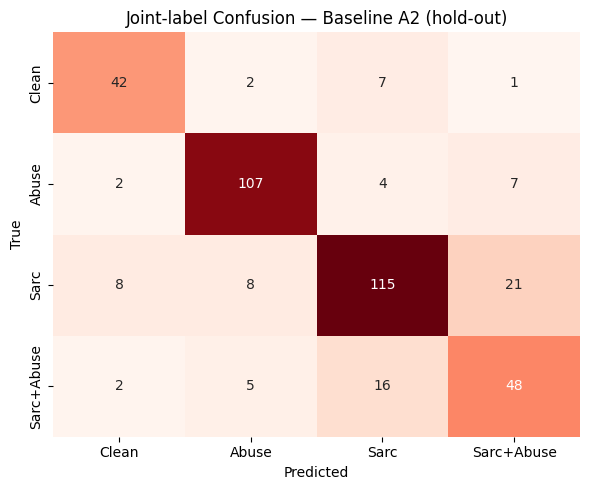


── Error rate by stratum (any-label error) ──
  By emoji presence:
    emoji=False:  20.0% (n=5)
    emoji=True :  21.0% (n=390)
  By text length:
    short:  27.3% (n=132)
    med  :  23.7% (n=131)
    long :  12.1% (n=132)
  By emoji-ambiguity bucket:
    no-emoji:  13.9% (n=36)
    low     :  11.4% (n=105)
    mid     :  27.1% (n=203)
    high    :  21.6% (n=51)
  By true joint class:
    Abuse      : sarc-err   9.2% (n=120) | off-err   5.0% (n=120)
    Clean      : sarc-err  15.4% (n=52) | off-err   5.8% (n=52)
    Sarc       : sarc-err  10.5% (n=152) | off-err  19.1% (n=152)
    Sarc+Abuse : sarc-err   9.9% (n=71) | off-err  25.4% (n=71)

Sample missed sarcasm:
   আপনার সুন্দর কণ্ঠ শুনতেই অপেক্ষা করছি 😣
   ঘুমাতে পারিনা সারারাত ধরে, বুকের ভেতর টা হাহাকার করে 😭
   তোমার উপর রাগ না 😡
   মানুষ হ 😭
Sample missed offensive:
   আপনার সুন্দর কণ্ঠ শুনতেই অপেক্ষা করছি 😣
   মানুষ হ 😭
   আমি অভিভূত 😑
   পারেনা ঠিক করে বাংলা বলতে , আবার বলবে ইংরেজি 😆

── Cross-model error overlap (any-label 

In [28]:
from scipy.stats import pointbiserialr

res = df_test.copy()
res["pred_sarc"] = sarc_pred; res["pred_off"] = off_pred
res["err_sarc"] = (res.sarcasm != res.pred_sarc).astype(int)
res["err_off"]  = (res.offensive != res.pred_off).astype(int)
res["any_err"]  = ((res.err_sarc + res.err_off) > 0).astype(int)

sfn = res[(res.sarcasm==1)&(res.pred_sarc==0)]; sfp = res[(res.sarcasm==0)&(res.pred_sarc==1)]
ofn = res[(res.offensive==1)&(res.pred_off==0)]; ofp = res[(res.offensive==0)&(res.pred_off==1)]
print("=== ERROR ANALYSIS (hold-out, Baseline A2 ensemble) ===")
print(f"Sarcasm  FN/FP: {len(sfn)}/{len(sfp)}   Offensive FN/FP: {len(ofn)}/{len(ofp)}")

# ---------- (1) CONTINUOUS emoji-ambiguity score -------------------------------
def ambiguity_score(text):
    """Mean over a text's emojis of how close their TRAIN propensities sit to 0.5
    (1 = maximally ambiguous, 0 = decisive). 0 if no scored emoji present.
    Diagnostic only — these statistics are NOT an input to the A2 model."""
    vals = []
    for e in extract_emojis(text):
        if e in explain_encoder.sarc_prop:
            sa = 1 - abs(2*explain_encoder.sarc_prop[e] - 1)
            oa = 1 - abs(2*explain_encoder.off_prop[e]  - 1)
            vals.append((sa + oa) / 2)
    return float(np.mean(vals)) if vals else 0.0

res["ambiguity"] = res.text.apply(ambiguity_score)
emoji_rows = res[res.text.apply(lambda t: len(extract_emojis(t))>0)]
if emoji_rows.ambiguity.std() > 0:
    r, p = pointbiserialr(emoji_rows.any_err, emoji_rows.ambiguity)
    print(f"\nContinuous ambiguity vs error (emoji rows): point-biserial r={r:+.3f} (p={p:.3g})")
    print(f"  mean ambiguity — correct: {emoji_rows[emoji_rows.any_err==0].ambiguity.mean():.3f} | "
          f"wrong: {emoji_rows[emoji_rows.any_err==1].ambiguity.mean():.3f}")

# ---------- (2) MULTI-LABEL (joint) confusion ----------------------------------
JMAP = {(0,0):"Clean",(0,1):"Abuse",(1,0):"Sarc",(1,1):"Sarc+Abuse"}
JLAB = ["Clean","Abuse","Sarc","Sarc+Abuse"]
res["true_joint"] = [JMAP[(s,o)] for s,o in zip(res.sarcasm, res.offensive)]
res["pred_joint"] = [JMAP[(s,o)] for s,o in zip(res.pred_sarc, res.pred_off)]
jcm = pd.crosstab(pd.Categorical(res.true_joint, JLAB),
                  pd.Categorical(res.pred_joint, JLAB), dropna=False).reindex(index=JLAB, columns=JLAB, fill_value=0)
print("\n── Joint (multi-label) confusion — rows=true, cols=pred ──")
print(jcm.to_string())
import seaborn as sns
plt.figure(figsize=(6,5))
sns.heatmap(jcm, annot=True, fmt="d", cmap="Reds", cbar=False)
plt.title("Joint-label Confusion — Baseline A2 (hold-out)"); plt.ylabel("True"); plt.xlabel("Predicted")
plt.tight_layout(); plt.savefig("error_joint_confusion.png", dpi=150, bbox_inches="tight"); plt.show()

# ---------- (3) WHY: stratified error rates ------------------------------------
def _rate(frame, col): return f"{frame[col].mean()*100:5.1f}% (n={len(frame)})"
res["has_emoji"] = res.text.apply(lambda t: len(extract_emojis(t))>0)
res["len_words"] = res.text.str.split().apply(len)
res["len_bin"]   = pd.qcut(res.len_words.rank(method="first"), q=3, labels=["short","med","long"])
res["amb_bin"]   = pd.cut(res.ambiguity, bins=[-0.01,0.001,0.34,0.67,1.01],
                          labels=["no-emoji","low","mid","high"])
print("\n── Error rate by stratum (any-label error) ──")
print("  By emoji presence:")
for k, g in res.groupby("has_emoji"):   print(f"    emoji={k!s:5}: {_rate(g,'any_err')}")
print("  By text length:")
for k, g in res.groupby("len_bin", observed=True):    print(f"    {str(k):5}: {_rate(g,'any_err')}")
print("  By emoji-ambiguity bucket:")
for k, g in res.groupby("amb_bin", observed=True):    print(f"    {str(k):8}: {_rate(g,'any_err')}")
print("  By true joint class:")
for k, g in res.groupby("true_joint"):  print(f"    {k:11}: sarc-err {_rate(g,'err_sarc')} | off-err {_rate(g,'err_off')}")

print("\nSample missed sarcasm:"); [print("  ", t) for t in sfn.text.head(4)]
print("Sample missed offensive:"); [print("  ", t) for t in ofn.text.head(4)]

# ---------- (4) CROSS-MODEL error comparison (A2 vs ablations vs Full) ---------
def err_idx(sp_pred, op_pred):
    return set(np.where((sp_pred!=sarc_true)|(op_pred!=off_true))[0])
a2_err = err_idx(sarc_pred, off_pred)
print("\n── Cross-model error overlap (any-label errors on the same test set) ──")
print(f"  A2 errors: {len(a2_err)}")
_others = [(name, r["sarc_pred"], r["off_pred"]) for name, r in abl_results.items()]
if REF_AVAILABLE:
    _others.append(("Full (intent vector)", ref_sarc_pred, ref_off_pred))
for name, spd, opd in _others:
    ae = err_idx(spd, opd)
    inter, union = a2_err & ae, a2_err | ae
    jac = len(inter)/max(len(union),1)
    print(f"  {name:<34} errors={len(ae):3d} | shared={len(inter):3d} "
          f"| A2-only={len(a2_err-ae):3d} | other-only={len(ae-a2_err):3d} "
          f"| Jaccard={jac:.2f}")
print("  (High Jaccard ⇒ systematic errors shared across variants; low ⇒ arm-specific.)")
if REF_AVAILABLE:
    _ref_err = err_idx(ref_sarc_pred, ref_off_pred)
    print(f"\n  Errors A2 makes that the Full model does NOT: {len(a2_err - _ref_err)}")
    print("  (These are the cases the intent vector rescues — inspect them for the write-up.)")


## Section 18 — Emoji Intent Space (train-fit, no leakage) — *diagnostic*

Scatter of each emoji's **sarcasm** vs **offensive** propensity, from the train/CV-pool
encoder of Section 14. In the reference pipeline this space *is* the model input; in
**A2 it is purely descriptive** — the very structure the baseline discards. Distinct
clusters here mean there was measurable intent structure available; whether the model
needed it explicitly is what the Section 16 comparison answers.


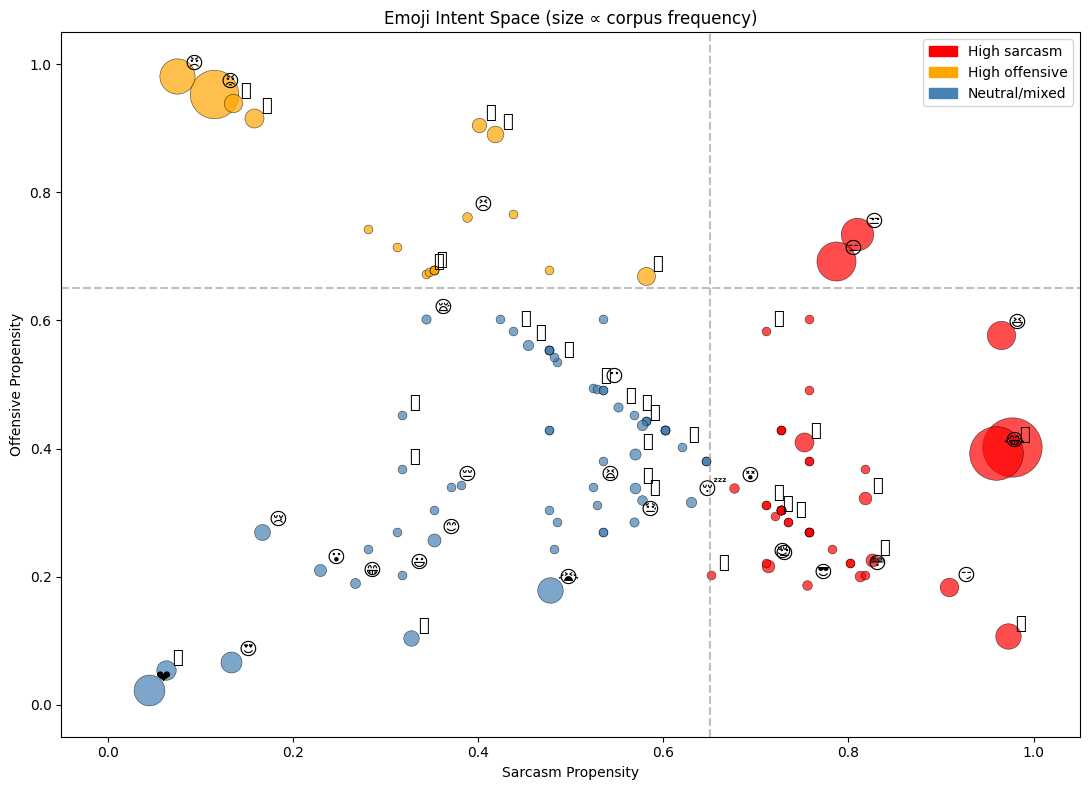

In [29]:
import matplotlib.patches as mpatches
rows = [{"emoji": e, "sarc": explain_encoder.sarc_prop[e], "off": explain_encoder.off_prop[e],
         "n": emoji_freq.get(e,0)} for e in explain_encoder.sarc_prop]
edf = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(11, 8))
for _, r in edf.iterrows():
    c = "red" if r.sarc>0.65 else ("orange" if r.off>0.65 else "steelblue")
    ax.scatter(r.sarc, r.off, s=max(40, r.n*4), c=c, alpha=.7, edgecolors="k", linewidths=.4)
    if r.n >= 8: ax.annotate(r.emoji, (r.sarc, r.off), xytext=(5,5), textcoords="offset points", fontsize=13)
ax.axhline(.65, ls="--", c="gray", alpha=.5); ax.axvline(.65, ls="--", c="gray", alpha=.5)
ax.set_xlabel("Sarcasm Propensity"); ax.set_ylabel("Offensive Propensity")
ax.set_title("Emoji Intent Space (size ∝ corpus frequency)")
ax.legend(handles=[mpatches.Patch(color="red", label="High sarcasm"),
                   mpatches.Patch(color="orange", label="High offensive"),
                   mpatches.Patch(color="steelblue", label="Neutral/mixed")])
ax.set_xlim(-.05,1.05); ax.set_ylim(-.05,1.05)
plt.tight_layout(); plt.savefig("emoji_intent_space.png", dpi=150, bbox_inches="tight"); plt.show()

## Section 19 — Statistical Significance Suite

A consolidated protocol reporting **effect + uncertainty + p-value** for Baseline A2:
(1) **bootstrap** 95% CIs and a label-permutation *p* for performance-vs-random;
(2) **McNemar** (one-sided) for A2 > each ablation and, crucially, **Full > A2** on the
shared hold-out set — the sample-level counterpart of the paired *t*-test in Section 16;
(2b) a **paired bootstrap CI on the Δ macro-F1 (Full − A2)**, so the intent-vector effect
is reported as an interval rather than a bare *p*; (3) paired ***t*-test + Wilcoxon** that
emoji tokens outweigh word tokens in LIME; (4) **χ²** task-dependence recap; (5)
**cross-fold variance** stability (std < 0.02). All results are exported as `a2_*.csv`.

*Reviewer Q&A — "Are the gains significant, not luck?"* Every headline claim is paired
with a hypothesis test and an interval; reported *p*-values are the real computed values.
A null Full-vs-A2 result is reported as such rather than hidden.


In [30]:
from scipy.stats import chi2 as _chi2dist, binomtest, wilcoxon, ttest_rel

# ============================================================================
# Helpers
# ============================================================================
mf   = lambda yt, yp: f1_score(yt, (yp>=.5).astype(int), average="macro", zero_division=0)
accf = lambda yt, yp: accuracy_score(yt, (yp>=.5).astype(int))
aucf = lambda yt, yp: roc_auc_score(yt, yp)

def bootstrap_ci(y_true, y_prob, metric_fn, B=None, alpha=0.05):
    B = CFG["BOOTSTRAP_N"] if B is None else B
    rng = np.random.default_rng(SEED); n = len(y_true); vals = np.full(B, np.nan)
    for i in range(B):
        idx = rng.integers(0, n, n)
        try:
            vals[i] = metric_fn(y_true[idx], y_prob[idx])
        except Exception:
            pass
    lo, hi = np.nanpercentile(vals, [100*alpha/2, 100*(1-alpha/2)])
    return np.nanmean(vals), lo, hi, vals

def perm_pvalue(y_true, y_prob, metric_fn, observed, P=None):
    """Label-permutation null: p = P(metric under shuffled labels >= observed)."""
    P = CFG["PERM_N"] if P is None else P
    rng = np.random.default_rng(SEED); null = np.empty(P)
    for i in range(P):
        null[i] = metric_fn(rng.permutation(y_true), y_prob)
    return (np.sum(null >= observed) + 1) / (P + 1)

def mcnemar(correct_a, correct_b):
    """One-sided McNemar for H1: model A is better than model B."""
    b = int(np.sum(correct_a & ~correct_b))
    c = int(np.sum(~correct_a & correct_b))
    n = b + c
    if n == 0: return b, c, 1.0
    if n < 25: p = binomtest(min(b, c), n, 0.5).pvalue
    else:      p = _chi2dist.sf((abs(b-c)-1)**2 / n, 1)
    p_one = p/2 if b > c else 1 - p/2
    return b, c, p_one

# ============================================================================
# TEST 1 — BOOTSTRAP: A2 performance > random
# ============================================================================
print("="*70); print("TEST 1 — BOOTSTRAP 95% CI + permutation p-value (A2 Performance > Random)"); print("="*70)
boot_rows = []
for task, yt, yp in [("Sarcasm", sarc_true, sarc_prob), ("Offensive", off_true, off_prob)]:
    for mname, fn in [("macroF1", mf), ("accuracy", accf), ("AUC", aucf)]:
        m, lo, hi, _ = bootstrap_ci(yt, yp, fn)
        obs = fn(yt, yp)
        p = perm_pvalue(yt, yp, fn, obs)
        boot_rows.append({"task": task, "metric": mname, "value": obs,
                          "CI95_low": lo, "CI95_high": hi, "p_vs_random": p})
        print(f"  {task:9} {mname:8}: {obs:.4f}  95%CI[{lo:.4f}, {hi:.4f}]  p(>random)={p:.1e}")
boot_df = pd.DataFrame(boot_rows)

# ============================================================================
# TEST 2 — McNEMAR: A2 > ablations, and Full > A2 (paired, same hold-out set)
# ============================================================================
print("\n" + "="*70); print("TEST 2 — McNEMAR (one-sided), paired on the hold-out test set"); print("="*70)
mcn_rows = []
for name, r in abl_results.items():
    for task, ytrue, apred, bpred in [
            ("Sarcasm", sarc_true, sarc_pred, r["sarc_pred"]),
            ("Offensive", off_true, off_pred, r["off_pred"])]:
        ca = (apred == ytrue); cb = (bpred == ytrue)
        b, c, p = mcnemar(ca, cb)
        mcn_rows.append({"comparison": f"A2 > {name}", "task": task,
                         "A_only_correct": b, "B_only_correct": c, "p_one_sided": p})
        print(f"  A2 vs {name:<28} [{task:9}] A2-only={b:3d} other-only={c:3d}  p={p:.4f}")

if REF_AVAILABLE:
    print("\n  >>> HYPOTHESIS OF RECORD — Full (intent vector) > A2 (no intent vector):")
    for task, ytrue, fpred, apred in [
            ("Sarcasm", sarc_true, ref_sarc_pred, sarc_pred),
            ("Offensive", off_true, ref_off_pred, off_pred)]:
        cf = (fpred == ytrue); ca = (apred == ytrue)
        b, c, p = mcnemar(cf, ca)
        mcn_rows.append({"comparison": "Full > A2", "task": task,
                         "A_only_correct": b, "B_only_correct": c, "p_one_sided": p})
        print(f"      [{task:9}] Full-only={b:3d} A2-only={c:3d}  p(1-sided)={p:.4f}  "
              f"{'SIGNIFICANT' if p < 0.05 else 'n.s.'}")
else:
    print("\n  >>> Full > A2 McNemar: UNAVAILABLE (no reference checkpoint).")
mcn_df = pd.DataFrame(mcn_rows)

# ============================================================================
# TEST 2b — BOOTSTRAP CI on Δ macro-F1 (Full − A2), paired resampling
# ============================================================================
print("\n" + "="*70); print("TEST 2b — BOOTSTRAP 95% CI on Δ macro-F1 (Full − A2), paired resampling"); print("="*70)
delta_rows = []
if REF_AVAILABLE:
    _rng = np.random.default_rng(SEED)
    for task, yt, p_full, p_a2 in [("Sarcasm", sarc_true, ref_sarc_prob, sarc_prob),
                                   ("Offensive", off_true, ref_off_prob, off_prob)]:
        n = len(yt); d = np.full(CFG["BOOTSTRAP_N"], np.nan)
        for i in range(CFG["BOOTSTRAP_N"]):
            idx = _rng.integers(0, n, n)      # SAME indices for both arms -> paired
            try:
                d[i] = mf(yt[idx], p_full[idx]) - mf(yt[idx], p_a2[idx])
            except Exception:
                pass
        obs = mf(yt, p_full) - mf(yt, p_a2)
        lo, hi = np.nanpercentile(d, [2.5, 97.5])
        excl = "excludes 0 (significant)" if (lo > 0 or hi < 0) else "includes 0 (n.s.)"
        delta_rows.append({"task": task, "delta_macroF1": obs, "CI95_low": lo, "CI95_high": hi,
                           "verdict": excl})
        print(f"  {task:9}: Δ={obs:+.4f}  95%CI[{lo:+.4f}, {hi:+.4f}]  -> {excl}")
else:
    print("  UNAVAILABLE (no reference checkpoint).")
delta_df = pd.DataFrame(delta_rows)

# ============================================================================
# TEST 3 — t-TEST on LIME weights: Emoji > Words (A2 ensemble)
# ============================================================================
print("\n" + "="*70); print("TEST 3 — Emoji > Word contribution (paired t-test on LIME weights, A2)"); print("="*70)
lime_idx = cand[:CFG["N_LIME_EXAMPLES"]]
tt_rows = []
for task, names in [("sarcasm", ["Non-Sarc","Sarc"]), ("offensive", ["Non-Off","Off"])]:
    em_means, wd_means = [], []
    for i in tqdm(lime_idx, desc=f"LIME[{task}]", leave=False):
        exp = lime_explain_pre(df_test.text.iloc[i], task, names, num_samples=CFG["LIME_SAMPLES"])
        em, wd = emoji_word_split(exp)
        if em and wd:
            em_means.append(np.mean([abs(w) for _, w in em]))
            wd_means.append(np.mean([abs(w) for _, w in wd]))
    em_means, wd_means = np.array(em_means), np.array(wd_means)
    if len(em_means) >= 3:
        t, p2 = ttest_rel(em_means, wd_means)
        p_t = p2/2 if t > 0 else 1 - p2/2
        try:
            _, p_w2 = wilcoxon(em_means, wd_means, alternative="greater")
        except Exception:
            p_w2 = float("nan")
        print(f"  {task:9}: n={len(em_means)}  mean|w| emoji={em_means.mean():.4f} > word={wd_means.mean():.4f}  "
              f"| t={t:+.3f} p(t,1-sided)={p_t:.2e} | Wilcoxon p={p_w2:.2e}")
        tt_rows.append({"task": task, "n": len(em_means), "emoji_mean": em_means.mean(),
                        "word_mean": wd_means.mean(), "t": t, "p_ttest": p_t, "p_wilcoxon": p_w2})
    else:
        print(f"  {task:9}: too few paired examples (n={len(em_means)}) for a stable test.")
ttest_df = pd.DataFrame(tt_rows)
print("  (In A2 these weights describe the model's ONLY pathway — emoji phrases are")
print("   carrying whatever emoji signal the model uses.)")

# ============================================================================
# TEST 4 — CHI-SQUARE: tasks related (recap from Section 16)
# ============================================================================
print("\n" + "="*70); print("TEST 4 — CHI-SQUARE (tasks related)"); print("="*70)
print(f"  χ²={TASKREL['chi2']:.2f}  dof={TASKREL['dof']}  p={TASKREL['p']:.2e}  φ={TASKREL['phi']:+.3f}  "
      f"({'related' if TASKREL['p']<0.05 else 'independent'})")

# ============================================================================
# TEST 5 — CV VARIANCE: results stable (std < 0.02)
# ============================================================================
print("\n" + "="*70); print("TEST 5 — STABILITY (std < 0.02)"); print("="*70)
a2_fold_std = a2_cv["metrics"]["macro_f1"].std()
sarc_cv_std = a2_cv["metrics"]["sarc_f1_macro"].std()
off_cv_std  = a2_cv["metrics"]["off_f1_macro"].std()
print(f"  A2 across-fold macro-F1 std    : {a2_fold_std:.4f}  {'✅' if a2_fold_std<0.02 else '⚠️'}")
print(f"  A2 across-fold sarc/off std    : {sarc_cv_std:.4f} / {off_cv_std:.4f}  "
      f"{'✅' if max(sarc_cv_std,off_cv_std)<0.02 else '⚠️'}")
if REF_AVAILABLE:
    print(f"  Reference across-fold std      : {ref_fold_macro.std():.4f}")

# ============================================================================
# FINAL REPORT
# ============================================================================
print("\n" + "="*70); print("FINAL REPORT — Baseline A2 (5-Fold CV Ensemble) | 95% CI (bootstrap) | p(>random)"); print("="*70)
report = []
for task, yt, yp in [("Sarcasm", sarc_true, sarc_prob), ("Offensive", off_true, off_prob)]:
    obs = mf(yt, yp)
    _, lo, hi, _ = bootstrap_ci(yt, yp, mf)
    pr = perm_pvalue(yt, yp, mf, obs)
    report.append({"task": task, "metric": "macro-F1",
                   "value": round(obs, 4),
                   "CI95": f"[{lo:.4f}, {hi:.4f}]",
                   "p_vs_random": f"{pr:.1e}"})
report_df = pd.DataFrame(report)
print(report_df.to_string(index=False))

# persist everything for the paper
report_df.to_csv(os.path.join(CFG["RUN_DIR"], "a2_statistical_report.csv"), index=False)
boot_df.to_csv(os.path.join(CFG["RUN_DIR"], "a2_bootstrap_ci.csv"), index=False)
if len(mcn_df):   mcn_df.to_csv(os.path.join(CFG["RUN_DIR"], "a2_mcnemar.csv"), index=False)
if len(delta_df): delta_df.to_csv(os.path.join(CFG["RUN_DIR"], "a2_delta_ci_vs_full.csv"), index=False)
if len(ttest_df): ttest_df.to_csv(os.path.join(CFG["RUN_DIR"], "a2_lime_ttest.csv"), index=False)
print(f"\nSaved: a2_statistical_report.csv, a2_bootstrap_ci.csv, a2_mcnemar.csv, "
      f"a2_delta_ci_vs_full.csv, a2_lime_ttest.csv -> {CFG['RUN_DIR']}")


TEST 1 — BOOTSTRAP 95% CI + permutation p-value (A2 Performance > Random)
  Sarcasm   macroF1 : 0.8921  95%CI[0.8579, 0.9226]  p(>random)=5.0e-04
  Sarcasm   accuracy: 0.8937  95%CI[0.8608, 0.9241]  p(>random)=5.0e-04
  Sarcasm   AUC     : 0.9516  95%CI[0.9276, 0.9728]  p(>random)=5.0e-04
  Offensive macroF1 : 0.8582  95%CI[0.8227, 0.8910]  p(>random)=5.0e-04
  Offensive accuracy: 0.8582  95%CI[0.8228, 0.8911]  p(>random)=5.0e-04
  Offensive AUC     : 0.9454  95%CI[0.9246, 0.9636]  p(>random)=5.0e-04

TEST 2 — McNEMAR (one-sided), paired on the hold-out test set
  A2 vs A0 No-emoji (text only)      [Sarcasm  ] A2-only= 64 other-only= 13  p=0.0000
  A2 vs A0 No-emoji (text only)      [Offensive] A2-only= 46 other-only= 27  p=0.0176
  A2 vs A1 A2 w/o cross-stitch       [Sarcasm  ] A2-only=  3 other-only=  5  p=0.6367
  A2 vs A1 A2 w/o cross-stitch       [Offensive] A2-only=  3 other-only= 11  p=0.9713

  >>> Full > A2 McNemar: UNAVAILABLE (no reference checkpoint).

TEST 2b — BOOTSTRAP 9

LIME[sarcasm]:   0%|          | 0/40 [00:00<?, ?it/s]

  sarcasm  : too few paired examples (n=0) for a stable test.


LIME[offensive]:   0%|          | 0/40 [00:00<?, ?it/s]

  offensive: too few paired examples (n=0) for a stable test.
  (In A2 these weights describe the model's ONLY pathway — emoji phrases are
   carrying whatever emoji signal the model uses.)

TEST 4 — CHI-SQUARE (tasks related)
  χ²=374.85  dof=1  p=1.65e-83  φ=-0.378  (related)

TEST 5 — STABILITY (std < 0.02)
  A2 across-fold macro-F1 std    : 0.0090  ✅
  A2 across-fold sarc/off std    : 0.0046 / 0.0162  ✅

FINAL REPORT — Baseline A2 (5-Fold CV Ensemble) | 95% CI (bootstrap) | p(>random)
     task   metric  value             CI95 p_vs_random
  Sarcasm macro-F1 0.8921 [0.8579, 0.9226]     5.0e-04
Offensive macro-F1 0.8582 [0.8227, 0.8910]     5.0e-04

Saved: a2_statistical_report.csv, a2_bootstrap_ci.csv, a2_mcnemar.csv, a2_delta_ci_vs_full.csv, a2_lime_ttest.csv -> /kaggle/working/runs


## Section 20 — Baseline A2: Resolution Summary

A checklist mapping the A2 experiment to its evidence: the emoji→Bangla-phrase expansion
that A2 retains, the intent pathway it removes, the controls that make the comparison
valid (shared folds, seed, hyper-parameters, loss, cross-stitch and SupCon), and the
statistical verdict on whether explicit propensity statistics add signal beyond emoji text.


In [31]:
print("Pipeline complete — BASELINE A2 (Emoji-Expanded Text, NO Intent Vector).")
print(f"  Architecture               : BanglaBERT [CLS] (768) -> shared({BEST_HP['shared_dim']}) "
      f"-> cross-stitch -> 2 heads")
print(f"  Ablated factor             : EmojiIntentEncoder features + EmoIntentMLP projection + concat")
print(f"  Preserved controls         : seed={CFG['ABLATION_SEED']} | folds={len(a2_cv['fold_indices'])} "
      f"(shared with reference) | HP={BEST_HP}")
print(f"                               weight_decay={CFG['WEIGHT_DECAY']} | warmup={CFG['WARMUP_RATIO']} | "
      f"max_epochs={CFG['MAX_EPOCHS']} | patience={CFG['PATIENCE']}")
print(f"                               cross-stitch + uncertainty-weighted MTL + SupCon(w={CFG['SUPCON_W']}) retained")
print(f"  CV macro-F1 (A2)           : {a2_cv['metrics']['macro_f1'].mean():.4f} "
      f"± {a2_cv['metrics']['macro_f1'].std():.4f}")
print(f"  TEST macro-F1 (A2)         : sarc {f1_score(sarc_true, sarc_pred, average='macro', zero_division=0):.4f} | "
      f"off {f1_score(off_true, off_pred, average='macro', zero_division=0):.4f}")
if REF_AVAILABLE:
    print(f"  CV macro-F1 (Full/intent)  : {ref_fold_macro.mean():.4f} ± {ref_fold_macro.std():.4f}")
    print(f"  Δ (Full − A2), CV folds    : {ref_fold_macro.mean() - a2_cv['metrics']['macro_f1'].mean():+.4f}"
          f"   <- the value of the intent vector")
else:
    print("  Δ (Full − A2)              : n/a (reference checkpoint absent)")
print(f"  Task relationship          : φ={TASKREL['phi']:+.3f}, χ² p={TASKREL['p']:.1e} (significant, NEGATIVE)")
print("  Statistical tests          : bootstrap CIs, McNemar (A2>Abl; Full>A2), paired Δ-CI,")
print("                               LIME emoji>word t-test, χ², CV-variance")
print("  Explainability             : LIME on preprocessed text — unconditional (single pathway)")
print("  Saved figures: training_curves, confusion_matrices, roc_curves, calibration_reliability,")
print("                 robustness_delta_f1, lime_sarcasm, lime_offensive, lime_emoji_vs_word,")
print("                 error_joint_confusion, emoji_intent_space (.png)")
print("  Saved tables : a2_statistical_report / a2_bootstrap_ci / a2_mcnemar /")
print("                 a2_delta_ci_vs_full / a2_lime_ttest / a2_calibration / a2_robustness (.csv)")


Pipeline complete — BASELINE A2 (Emoji-Expanded Text, NO Intent Vector).
  Architecture               : BanglaBERT [CLS] (768) -> shared(512) -> cross-stitch -> 2 heads
  Ablated factor             : EmojiIntentEncoder features + EmoIntentMLP projection + concat
  Preserved controls         : seed=42 | folds=5 (shared with reference) | HP={'lr': 2e-05, 'batch_size': 16, 'dropout': 0.3, 'shared_dim': 512, 'task_dim': 256}
                               weight_decay=0.01 | warmup=0.1 | max_epochs=20 | patience=3
                               cross-stitch + uncertainty-weighted MTL + SupCon(w=0.1) retained
  CV macro-F1 (A2)           : 0.8903 ± 0.0090
  TEST macro-F1 (A2)         : sarc 0.8921 | off 0.8582
  Δ (Full − A2)              : n/a (reference checkpoint absent)
  Task relationship          : φ=-0.378, χ² p=1.6e-83 (significant, NEGATIVE)
  Statistical tests          : bootstrap CIs, McNemar (A2>Abl; Full>A2), paired Δ-CI,
                               LIME emoji>word t-test, χ